# Predicción de Enfermedad Arterial Coronaria

**Autor:** solfloreslab
**Fecha:** 23 de diciembre de 2025  
**Dataset:** Heart Disease - UCI Machine Learning Repository (Cleveland)

## 1. Introducción y Contexto Clínico

### 1.1 El Problema Clínico

La enfermedad arterial coronaria (CAD) es un problema clínico frecuente y potencialmente grave, siendo una de las principales causas de mortalidad a nivel mundial [1]. Si bien en países de altos ingresos el cáncer ha comenzado a equipararse como causa principal de mortalidad [2], las enfermedades cardiovasculares siguen representando un problema de salud pública prioritario.

La confirmación diagnóstica se apoya en la angiografía coronaria, un procedimiento invasivo que no se indica de forma sistemática a todos los pacientes con sospecha clínica, sino tras una evaluación escalonada basada en historia clínica, exploración y pruebas complementarias.

En este contexto, el reto asistencial no suele estar en los casos extremos (muy probables o muy improbables), sino en los pacientes con incertidumbre diagnóstica, donde los hallazgos pueden ser discordantes y la decisión de avanzar a pruebas más invasivas no es evidente. En el trabajo de Detrano et al. [3] se plantea precisamente que la utilidad de un algoritmo probabilístico es mayor en este escenario intermedio y, por ello, consideran especialmente relevante evaluar el rendimiento para probabilidades de decisión entre 0,20 y 0,80 en síndromes de dolor torácico.

### 1.2 Dataset Cleveland y Variables Disponibles

El dataset Cleveland corresponde al grupo de referencia utilizado por Detrano et al. [3] para derivar su modelo: 303 pacientes consecutivos remitidos a angiografía coronaria en Cleveland Clinic [4]. En el protocolo descrito, las historias clínicas, exploraciones físicas y pruebas no invasivas se realizaron dentro de las 6 semanas previas a la angiografía [3].

Las 13 variables recogen información de diferentes niveles del proceso diagnóstico (clínica, ECG y pruebas de esfuerzo, analítica y pruebas no invasivas). En el paper se especifica que, además del ECG de esfuerzo y la gammagrafía de talio, se incluye fluoroscopia para calcio coronario. En concreto, el dato fluoroscópico consistía en el número de vasos principales que parecían contener calcio, lo que ayuda a interpretar correctamente la variable `ca`.

### 1.3 Formulación del Problema de Machine Learning

Se plantea un problema de **clasificación binaria supervisada**, orientado a predecir la presencia de **enfermedad coronaria significativa** confirmada por angiografía.

En el estudio original [3], los angiogramas se consideraron anormales si existía **>50%** de estrechamiento luminal en algún vaso epicárdico principal. En el dataset, la salida original está codificada como 0–4; en este trabajo se binariza para obtener una clasificación clínica interpretable:

* **Clase 0:** ausencia de enfermedad significativa (estenosis < 50%).
* **Clase 1:** presencia de enfermedad significativa (estenosis > 50% en al menos un vaso).

Esta binarización es coherente con el criterio angiográfico de enfermedad utilizado como variable dependiente en la derivación del modelo del paper.


### 1.4 Métricas de Evaluación y Prioridad Clínica

En un escenario de soporte a la decisión clínica, el accuracy por sí solo puede ser insuficiente. Se prioriza el **Recall (sensibilidad)** para minimizar falsos negativos (pacientes con enfermedad significativa clasificados como sanos), dado que este tipo de error tiene consecuencias clínicas potencialmente graves, un paciente enfermo no detectado podría no recibir tratamiento oportuno.

Se complementa con Precision, F1-Score y ROC-AUC para obtener una visión completa del rendimiento del modelo.

Además, dado que la utilidad del modelo depende del umbral de decisión, resulta relevante evaluar su comportamiento en el rango de probabilidades donde la decisión clínica suele ser más difícil. En el paper [3] se justifica explícitamente el uso del intervalo 0,20–0,80 para decisiones relacionadas con angiografía o tratamiento.

## 2. Configuración del Entorno

Antes de comenzar, importamos las librerías necesarias y configuramos el entorno de trabajo. Siguiendo las buenas prácticas, establecemos una semilla para garantizar reproducibilidad de los resultados.

In [36]:
# ==============================================================================
# 2 IMPORTACIONES Y CONFIGURACIÓN INICIAL
# ==============================================================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Métricas
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, recall_score, precision_score, f1_score,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Configuración
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("="*70)
print("PREDICCIÓN DE ENFERMEDAD CORONARIA")
print("="*70)
print("Librerías cargadas correctamente")
print(f"Semilla para reproducibilidad: {RANDOM_STATE}")

PREDICCIÓN DE ENFERMEDAD CORONARIA
Librerías cargadas correctamente
Semilla para reproducibilidad: 42


## 3. Carga del Dataset

### 3.1 Lectura de los datos

El archivo `processed.cleveland.data` no incluye encabezados, por lo que asignamos los nombres de las 14 variables según la documentación de UCI [5].

**Consideraciones importantes:**
- El dataset utiliza el carácter `?` para indicar valores faltantes, por lo que usamos `na_values='?'` para convertirlos automáticamente a `NaN`.
- Implementamos un bloque `try/except` para cargar desde URL o archivo local, garantizando que el notebook funcione en cualquier entorno.

In [37]:
# ==============================================================================
# 3.1 CARGA DEL DATASET
# ==============================================================================

# Nombres de columnas según documentación UCI
column_names = [
    'age',      # Edad en años
    'sex',      # Sexo (1=masculino, 0=femenino)
    'cp',       # Tipo de dolor torácico (1-4)
    'trestbps', # Presión arterial en reposo (mmHg)
    'chol',     # Colesterol sérico (mg/dl)
    'fbs',      # Glucosa en ayunas >120 mg/dl (1=sí, 0=no)
    'restecg',  # Resultados ECG en reposo (0-2)
    'thalach',  # Frecuencia cardíaca máxima alcanzada
    'exang',    # Angina inducida por ejercicio (1=sí, 0=no)
    'oldpeak',  # Depresión ST inducida por ejercicio
    'slope',    # Pendiente del segmento ST (1-3)
    'ca',       #  Número de vasos principales que parecían contener calcio visible en fluoroscopia (0-3)
    'thal',     # Test de talio (3=normal, 6=defecto fijo, 7=defecto reversible)
    'target'    # Diagnóstico (0=sano, 1-4=grados de enfermedad)
]

# Cargar datos: intenta URL, si falla usa archivo local
try:
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
    df = pd.read_csv(url, names=column_names, na_values='?')
    print("Dataset cargado desde URL")
except:
    df = pd.read_csv('processed.cleveland.data', names=column_names, na_values='?')
    print("Dataset cargado desde archivo local")

print(f"Dimensiones: {df.shape[0]} pacientes x {df.shape[1]} variables")
print("\nPrimeras 5 filas:")
df.head()

Dataset cargado desde URL
Dimensiones: 303 pacientes x 14 variables

Primeras 5 filas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### 3.2 Inspección inicial del dataset

Antes de dividir los datos, realizamos una inspección básica que **no causa data leakage**: dimensiones, tipos de datos, valores faltantes y distribución del target. Esta información es necesaria para entender la estructura del dataset y preparar la binarización de la variable objetivo.

In [38]:
# ==============================================================================
# 3.2 INSPECCIÓN BÁSICA DEL DATASET (Pre-Split)
# ==============================================================================

print("="*70)
print("INSPECCIÓN INICIAL DEL DATASET")
print("="*70)

# Información general
print("\n--- Información general ---")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nTipos de datos:")
print(df.dtypes)

# Valores faltantes
print("\n--- Valores faltantes ---")
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df) * 100).round(2)
faltantes = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
print(faltantes[faltantes['Nulos'] > 0] if faltantes['Nulos'].sum() > 0 else "No hay valores faltantes")

print(f"\nTotal de valores faltantes: {df.isnull().sum().sum()}")

INSPECCIÓN INICIAL DEL DATASET

--- Información general ---
Dimensiones: 303 filas x 14 columnas

Tipos de datos:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

--- Valores faltantes ---
      Nulos  Porcentaje (%)
ca        4            1.32
thal      2            0.66

Total de valores faltantes: 6


### 3.3 Binarización de la variable objetivo

Como se explicó en la sección 1.3, binarizamos la variable original **0–4** (denominada **`num`** en la documentación UCI y cargada como **`target`** en este notebook) en dos clases:

* **0:** sin enfermedad significativa (valor original = 0).
* **1:** con enfermedad (valor original ∈ {1,2,3,4}).

Verificamos la distribución resultante para evaluar el balance de clases.

In [39]:
# ==============================================================================
# 3.3 BINARIZACIÓN DEL TARGET
# ==============================================================================

print("--- Distribución del target ORIGINAL (0-4) ---")
print(df['target'].value_counts().sort_index())

# Binarización: 0 = sano, 1+ = enfermo
df['target'] = (df['target'] > 0).astype(int)

print("\n--- Distribución del target BINARIZADO ---")
target_counts = df['target'].value_counts().sort_index()
print(target_counts)

print(f"\nClase 0 (sin enfermedad): {target_counts[0]} pacientes ({target_counts[0]/len(df)*100:.1f}%)")
print(f"Clase 1 (con enfermedad): {target_counts[1]} pacientes ({target_counts[1]/len(df)*100:.1f}%)")

# Evaluación del balance
ratio = min(target_counts) / max(target_counts)
print(f"\nRatio entre clases: {ratio:.2f}")
if ratio > 0.8:
    print("Conclusión: Las clases están BALANCEADAS - no se requiere tratamiento especial")
elif ratio > 0.5:
    print("Conclusión: Desbalance LEVE - monitorear métricas por clase")
else:
    print("Conclusión: Desbalance SIGNIFICATIVO - considerar técnicas de balanceo")

--- Distribución del target ORIGINAL (0-4) ---
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

--- Distribución del target BINARIZADO ---
target
0    164
1    139
Name: count, dtype: int64

Clase 0 (sin enfermedad): 164 pacientes (54.1%)
Clase 1 (con enfermedad): 139 pacientes (45.9%)

Ratio entre clases: 0.85
Conclusión: Las clases están BALANCEADAS - no se requiere tratamiento especial


La variable original muestra que la mayoría de pacientes están en 0 (sin enfermedad), y los grados 1–4 aparecen con menor frecuencia. Esto es esperable en un dataset clínico donde la severidad alta es menos común.

Tras la binarización, la distribución queda moderadamente equilibrada (54.1% sanos vs 45.9% con enfermedad). Esto permite entrenar modelos sin necesidad inmediata de técnicas de reequilibrio.

## 4. División Train/Test

### 4.1 Separación de características y variable objetivo

Antes de cualquier transformación o análisis detallado, dividimos los datos en conjuntos de entrenamiento y prueba. Este es el **paso más crítico para prevenir data leakage**, como se enfatiza en la literatura de ML, todas las decisiones de preprocesamiento deben basarse únicamente en el conjunto de entrenamiento.

Utilizamos división estratificada (`stratify=y`) para mantener la proporción de clases en ambos conjuntos, lo cual es especialmente importante en problemas de clasificación.

In [40]:
# ==============================================================================
# 4.1 DIVISIÓN TRAIN/TEST (PASO CRÍTICO - PREVENCIÓN DE DATA LEAKAGE)
# ==============================================================================

# Separar características (X) y variable objetivo (y)
X = df.drop('target', axis=1)
y = df['target']

# División estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # Mantiene proporción de clases en ambos conjuntos
)

print("="*70)
print("DIVISIÓN TRAIN/TEST COMPLETADA")
print("="*70)

print(f"\nConjunto de ENTRENAMIENTO:")
print(f"  - Muestras: {X_train.shape[0]} ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"  - Clase 0: {(y_train==0).sum()} | Clase 1: {(y_train==1).sum()}")

print(f"\nConjunto de PRUEBA:")
print(f"  - Muestras: {X_test.shape[0]} ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"  - Clase 0: {(y_test==0).sum()} | Clase 1: {(y_test==1).sum()}")

# Verificar estratificación
prop_train = (y_train==1).sum() / len(y_train) * 100
prop_test = (y_test==1).sum() / len(y_test) * 100
print(f"\nVerificación de estratificación:")
print(f"  - Proporción clase 1 en train: {prop_train:.1f}%")
print(f"  - Proporción clase 1 en test:  {prop_test:.1f}%")
print(f"  - Diferencia: {abs(prop_train - prop_test):.1f} puntos porcentuales")

DIVISIÓN TRAIN/TEST COMPLETADA

Conjunto de ENTRENAMIENTO:
  - Muestras: 242 (79.9%)
  - Clase 0: 131 | Clase 1: 111

Conjunto de PRUEBA:
  - Muestras: 61 (20.1%)
  - Clase 0: 33 | Clase 1: 28

Verificación de estratificación:
  - Proporción clase 1 en train: 45.9%
  - Proporción clase 1 en test:  45.9%
  - Diferencia: 0.0 puntos porcentuales


El particionado estratificado conserva exactamente la misma proporción de clase positiva en train y test (45.9% en ambos). Esto reduce el riesgo de que el rendimiento cambie por diferencias artificiales de distribución entre conjuntos.

## 5. Análisis Exploratorio de Datos (EDA)

A partir de este punto, todo el análisis se realiza **únicamente sobre el conjunto de entrenamiento** para evitar data leakage, siguiendo las mejores prácticas establecidas.

El objetivo del EDA es:
1. Evaluar la estructura y calidad de los datos (tipos, nulos, rangos).
2. Detectar posibles problemas (valores faltantes, outliers, desbalanceo).
3. Explorar patrones y relaciones entre variables.
4. Fundamentar las decisiones de preprocesamiento que se tomarán al final de esta sección.

### 5.1 Diccionario de Variables (Contexto Clínico)

Aunque varias variables aparecen codificadas como enteros en el dataset, su naturaleza clínica puede ser categórica. Este diccionario, basado en el paper de Detrano et al. (1989), permite interpretar correctamente el análisis y definir el preprocesamiento adecuado.

| Variable | Descripción Clínica | Tipo de Dato |
|:---------|:--------------------|:-------------|
| `age` | Edad del paciente en años. | Numérica continua |
| `sex` | Sexo biológico (1 = hombre, 0 = mujer). | Binaria |
| `cp` | Tipo de dolor torácico: típico (1), atípico (2), no anginoso (3), asintomático (4). | Nominal (4 categorías) |
| `trestbps` | Presión arterial sistólica en reposo (mm Hg). | Numérica continua |
| `chol` | Colesterol sérico (mg/dl). | Numérica continua |
| `fbs` | Glucemia en ayunas > 120 mg/dl (1 = sí, 0 = no). | Binaria |
| `restecg` | ECG en reposo: normal (0), alteración ST-T (1), hipertrofia ventricular (2). | Nominal (3 categorías) |
| `thalach` | Frecuencia cardíaca máxima alcanzada durante el ejercicio. | Numérica continua |
| `exang` | Angina inducida por ejercicio (1 = sí, 0 = no). | Binaria |
| `oldpeak` | Depresión del segmento ST inducida por ejercicio respecto al reposo. | Numérica continua |
| `slope` | Pendiente del ST en pico de ejercicio: ascendente (1), plana (2), descendente (3). | Nominal (3 categorías) |
| `ca` | Número de vasos principales (0-3) que parecían contener calcio visible en fluoroscopia. | Numérica discreta (ordinal) |
| `thal` | Test de talio: normal (3), defecto fijo (6), defecto reversible (7). | Nominal (3 categorías) |
| `target` | Diagnóstico angiográfico: 0 = estenosis < 50%, 1 = estenosis > 50% (valor original ∈{1,2,3,4}) . | Binaria (objetivo, derivada) |

**Nota importante:** Las variables `cp`, `restecg`, `slope` y `thal`, aunque aparecen como números, representan categorías clínicas sin orden matemático lineal. Por ejemplo, un dolor torácico "atípico" (2) no es "el doble" que "típico" (1). Esta distinción se tendrá en cuenta al definir el preprocesamiento.

### 5.2 Configuración visual e información general

In [41]:
# ==============================================================================
# 5.2 CONFIGURACIÓN VISUAL E INFORMACIÓN GENERAL
# ==============================================================================

# Configuración de estilo para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paleta de colores
COLOR_SANO = '#27ae60'
COLOR_ENFERMO = '#e74c3c'
COLOR_PRIMARY = '#3498db'
COLOR_SECONDARY = '#85c1e9'

# Preparar DataFrame de entrenamiento para EDA
df_train_eda = X_train.copy()
df_train_eda['target'] = y_train.values

print("="*70)
print("5.2 INFORMACIÓN GENERAL DEL CONJUNTO DE ENTRENAMIENTO")
print("="*70)

print(f"\nDimensiones: {df_train_eda.shape[0]} muestras x {df_train_eda.shape[1]} variables")

print("\nTipos de datos:")
print(df_train_eda.dtypes)

print("\nValores faltantes:")
missing = df_train_eda.isnull().sum()
missing_pct = (missing / len(df_train_eda) * 100).round(2)
missing_df = pd.DataFrame({'Nulos': missing, '%': missing_pct})
missing_df = missing_df[missing_df['Nulos'] > 0]
if len(missing_df) > 0:
    display(missing_df)
else:
    print("No hay valores faltantes.")

print("\nEstadísticas descriptivas:")
display(df_train_eda.describe().round(2).T)

5.2 INFORMACIÓN GENERAL DEL CONJUNTO DE ENTRENAMIENTO

Dimensiones: 242 muestras x 14 variables

Tipos de datos:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Valores faltantes:


,Nulos,%
ca,1,0.41
thal,1,0.41



Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
age,242.0,54.55,9.00,29.0,48.00,56.0,61.00,77.0
sex,242.0,0.68,0.47,0.0,0.00,1.0,1.00,1.0
cp,242.0,3.15,0.98,1.0,2.25,3.0,4.00,4.0
trestbps,242.0,130.96,17.62,94.0,120.00,130.0,140.00,200.0
chol,242.0,249.84,52.85,126.0,212.00,244.5,277.75,564.0
fbs,242.0,0.14,0.35,0.0,0.00,0.0,0.00,1.0
restecg,242.0,0.98,1.00,0.0,0.00,0.0,2.00,2.0
thalach,242.0,149.96,22.69,71.0,134.50,153.5,166.00,202.0
exang,242.0,0.33,0.47,0.0,0.00,0.0,1.00,1.0
oldpeak,242.0,1.00,1.12,0.0,0.00,0.8,1.60,6.2


La mayoría de variables están almacenadas como numéricas aunque varias representan categorías clínicas codificadas como enteros, lo que deberá tenerse en cuenta en el preprocesado.

Solo hay dos valores faltantes en el conjunto de entrenamiento: uno en ca y uno en thal (0.41% cada uno). La ausencia de valores faltantes en el resto de variables sugiere buena calidad del registro para el análisis.

Los rangos observados son compatibles con población remitida a estudio coronario (edad media en torno a 55 años, PA sistólica alrededor de 130 mmHg, colesterol medio ~250 mg/dl), con variabilidad esperable en parámetros de esfuerzo.

### 5.3 Distribución del Target (Balance de Clases)

Se analiza la proporción de clases para detectar posible desbalanceo que pudiera requerir técnicas específicas de tratamiento.

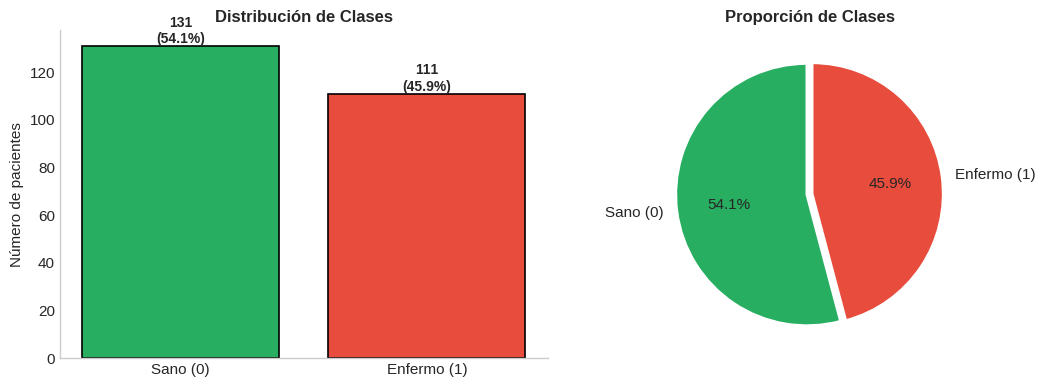

In [42]:
# ==============================================================================
# 5.3 DISTRIBUCIÓN DEL TARGET
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

target_counts = df_train_eda['target'].value_counts().sort_index()

# Gráfico de barras
ax1 = axes[0]
bars = ax1.bar(['Sano (0)', 'Enfermo (1)'], target_counts.values,
               color=[COLOR_SANO, COLOR_ENFERMO], edgecolor='black', linewidth=1.2)
ax1.set_ylabel('Número de pacientes', fontsize=11)
ax1.set_title('Distribución de Clases', fontsize=12, fontweight='bold')

for bar, count in zip(bars, target_counts.values):
    pct = count / len(df_train_eda) * 100
    ax1.annotate(f'{count}\n({pct:.1f}%)',
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Gráfico de pastel
ax2 = axes[1]
ax2.pie(target_counts.values, labels=['Sano (0)', 'Enfermo (1)'],
        autopct='%1.1f%%', colors=[COLOR_SANO, COLOR_ENFERMO],
        explode=(0.02, 0.02), startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Proporción de Clases', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.4 Distribuciones de Variables Numéricas

Se revisan las distribuciones de las variables continuas para detectar asimetrías, sesgos y rangos de valores.

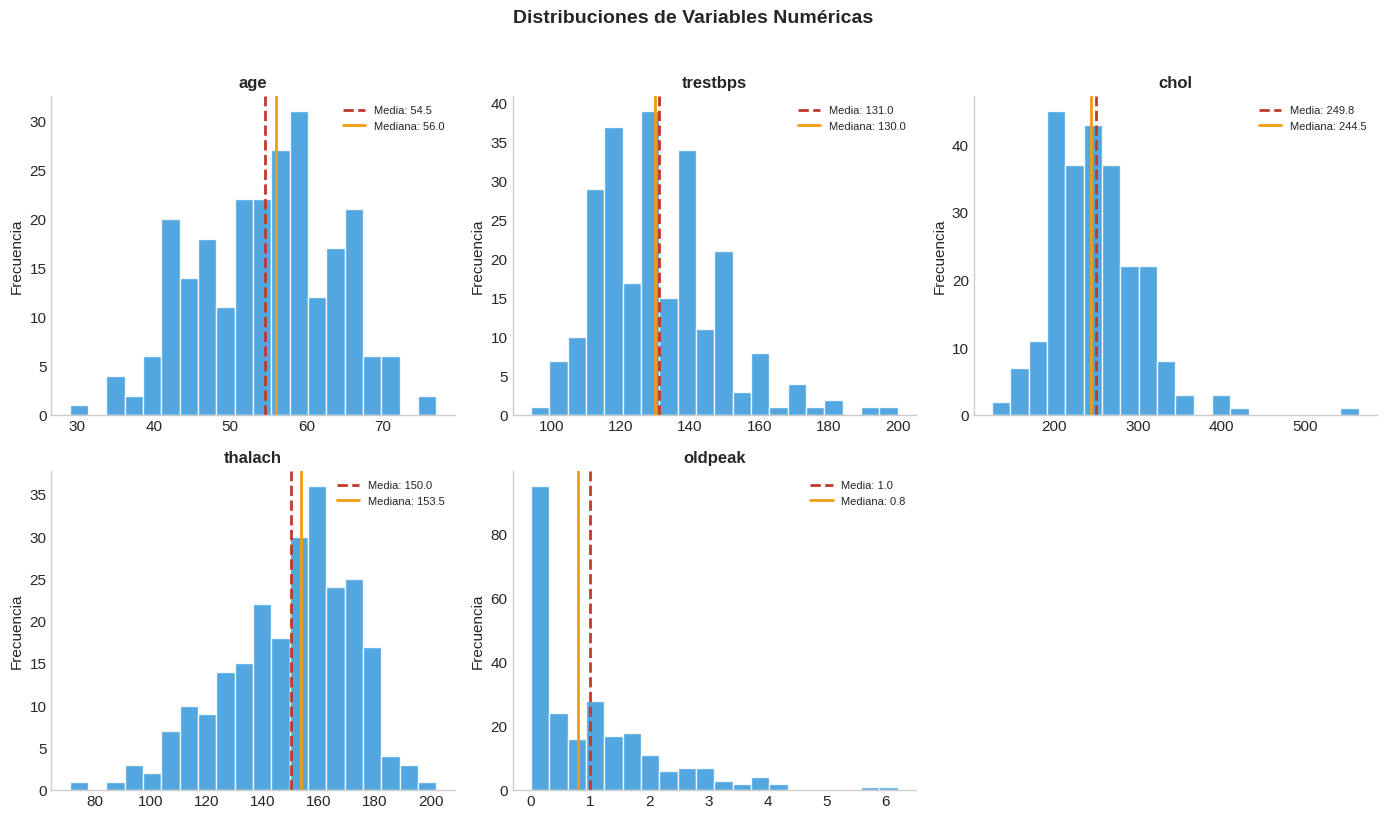

In [43]:
# ==============================================================================
# 5.4 DISTRIBUCIONES DE VARIABLES NUMÉRICAS (HISTOGRAMAS)
# ==============================================================================

numeric_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_vars):
    ax = axes[i]
    ax.hist(df_train_eda[col].dropna(), bins=20, color=COLOR_PRIMARY,
            edgecolor='white', linewidth=1, alpha=0.85)

    mean_val = df_train_eda[col].mean()
    median_val = df_train_eda[col].median()
    ax.axvline(mean_val, color='#c0392b', linestyle='--', linewidth=2, label=f'Media: {mean_val:.1f}')
    ax.axvline(median_val, color='#f39c12', linestyle='-', linewidth=2, label=f'Mediana: {median_val:.1f}')

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8, loc='upper right')

axes[5].axis('off')

plt.suptitle('Distribuciones de Variables Numéricas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Las distribuciones muestran que algunas variables presentan asimetría y colas (especialmente chol y oldpeak), con diferencias entre media y mediana. Esto es típico en variables biológicas y sugiere que las medidas robustas (mediana/IQR) describen mejor el centro que la media.

### 5.5 Detección de Outliers

Se identifican valores extremos mediante boxplots y el método del rango intercuartílico (IQR). Los outliers detectados serán considerados en la elección del método de escalado.

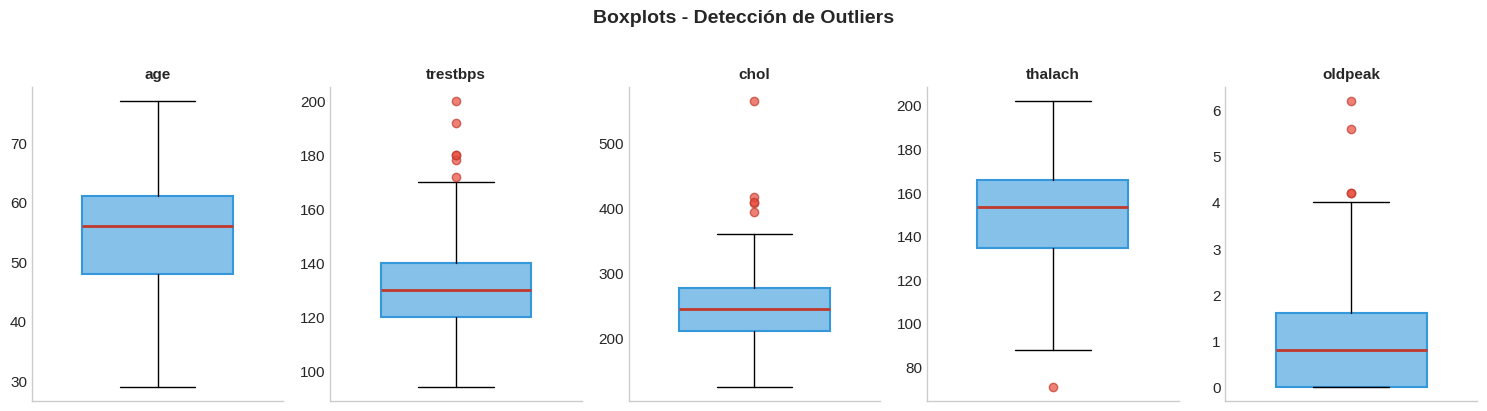

CONTEO DE OUTLIERS (Método IQR)
  trestbps: 6 outliers (2.5%)
  chol: 5 outliers (2.1%)
  thalach: 1 outliers (0.4%)
  oldpeak: 4 outliers (1.7%)


In [44]:
# ==============================================================================
# 5.5 DETECCIÓN DE OUTLIERS (BOXPLOTS + IQR)
# ==============================================================================

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, col in enumerate(numeric_vars):
    ax = axes[i]
    bp = ax.boxplot(df_train_eda[col].dropna(), patch_artist=True, widths=0.6)

    bp['boxes'][0].set_facecolor(COLOR_SECONDARY)
    bp['boxes'][0].set_edgecolor(COLOR_PRIMARY)
    bp['boxes'][0].set_linewidth(1.5)
    bp['medians'][0].set_color('#c0392b')
    bp['medians'][0].set_linewidth(2)

    for flier in bp['fliers']:
        flier.set(marker='o', markerfacecolor=COLOR_ENFERMO, markeredgecolor='#c0392b',
                  markersize=6, alpha=0.7)

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xticks([])

plt.suptitle('Boxplots - Detección de Outliers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Conteo de outliers
print("="*70)
print("CONTEO DE OUTLIERS (Método IQR)")
print("="*70)
for col in numeric_vars:
    Q1 = df_train_eda[col].quantile(0.25)
    Q3 = df_train_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df_train_eda[col] < Q1 - 1.5*IQR) | (df_train_eda[col] > Q3 + 1.5*IQR)).sum()
    if n_outliers > 0:
        print(f"  {col}: {n_outliers} outliers ({n_outliers/len(df_train_eda)*100:.1f}%)")

Se identifican outliers por IQR en trestbps, chol y oldpeak. En un contexto clínico, estos extremos pueden corresponder a pacientes reales (no necesariamente errores), por lo que se interpretan como variabilidad biológica/ clínica más que como valores a eliminar automáticamente.

### 5.6 Relaciones entre variables numéricas

Para explorar relaciones bivariadas entre las variables numéricas principales y detectar posibles patrones de separación entre clases, se utiliza un *pairplot* sobre el conjunto de entrenamiento.  
Este tipo de visualización permite observar tendencias (lineales o no), agrupamientos y posibles interacciones entre variables continuas que no siempre se aprecian en histogramas o boxplots.

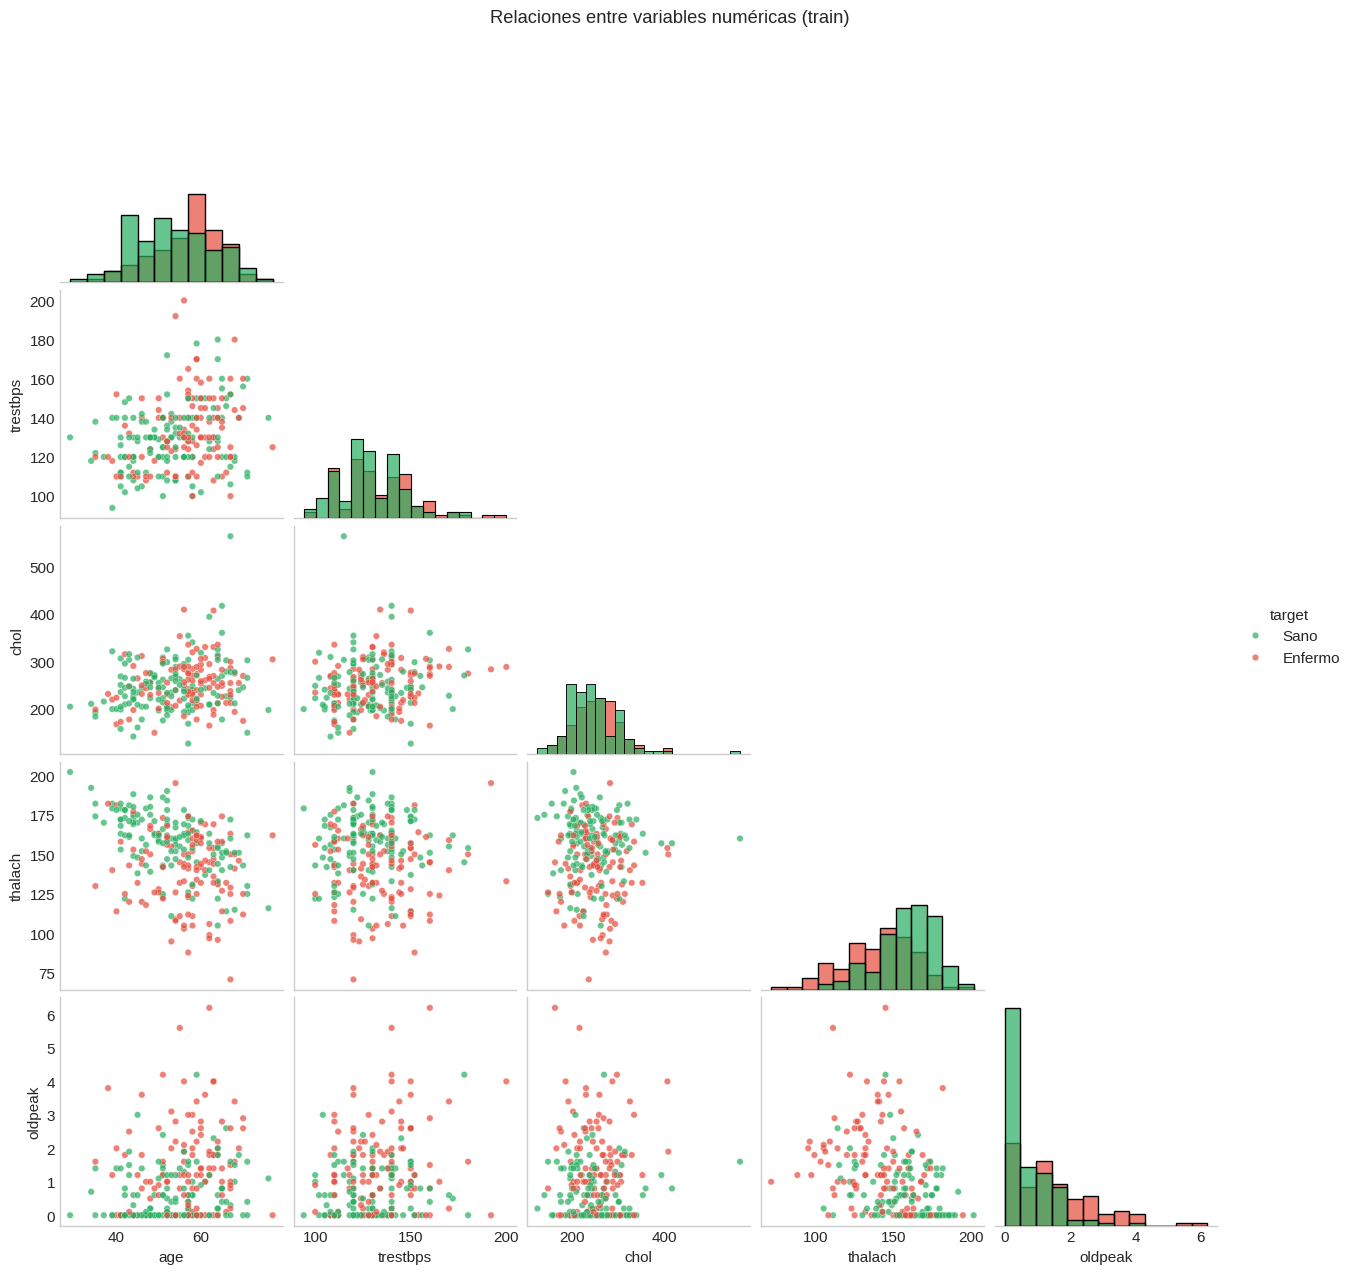

In [45]:
# ==============================================================================
# 5.6 RELACIONES ENTRE VARIABLES NUMÉRICAS (PAIRPLOT) - VERDE/ROJO
# ==============================================================================

num_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

tmp = df_train_eda[num_vars + ['target']].copy()
tmp['target'] = tmp['target'].map({0: 'Sano', 1: 'Enfermo'})

sns.pairplot(
    tmp,
    hue='target',
    hue_order=['Sano', 'Enfermo'],
    palette={'Sano': '#27ae60', 'Enfermo': '#e74c3c'},
    diag_kind='hist',
    corner=True,
    plot_kws={'alpha': 0.7, 's': 22, 'edgecolor': 'white', 'linewidth': 0.3},
    diag_kws={'alpha': 0.7}
)

plt.suptitle("Relaciones entre variables numéricas (train)", y=1.02)
plt.show()

El pairplot revela que las variables numéricas clásicas (edad, presión arterial, colesterol) no muestran una separación clara entre clases, con distribuciones altamente solapadas. Las variables con mejor discriminación visual son `thalach` (frecuencia cardíaca máxima) y `oldpeak` (depresión ST): los pacientes enfermos tienden a alcanzar frecuencias cardíacas máximas más bajas y presentan mayor depresión del segmento ST durante el ejercicio.

Este patrón es clínicamente coherente: la limitación funcional cardíaca por enfermedad coronaria impide alcanzar frecuencias altas, y la depresión ST es un marcador electrocardiográfico de isquemia miocárdica. El solapamiento en variables como edad y colesterol sugiere que, aunque son factores de riesgo cardiovascular conocidos, no son suficientemente discriminativos por sí solos para predecir enfermedad coronaria establecida.

### 5.7 Matriz de Correlación

Se calcula la correlación de Pearson entre variables numéricas. Dado que algunas variables son categóricas codificadas como números, esta correlación se interpreta como una aproximación exploratoria.

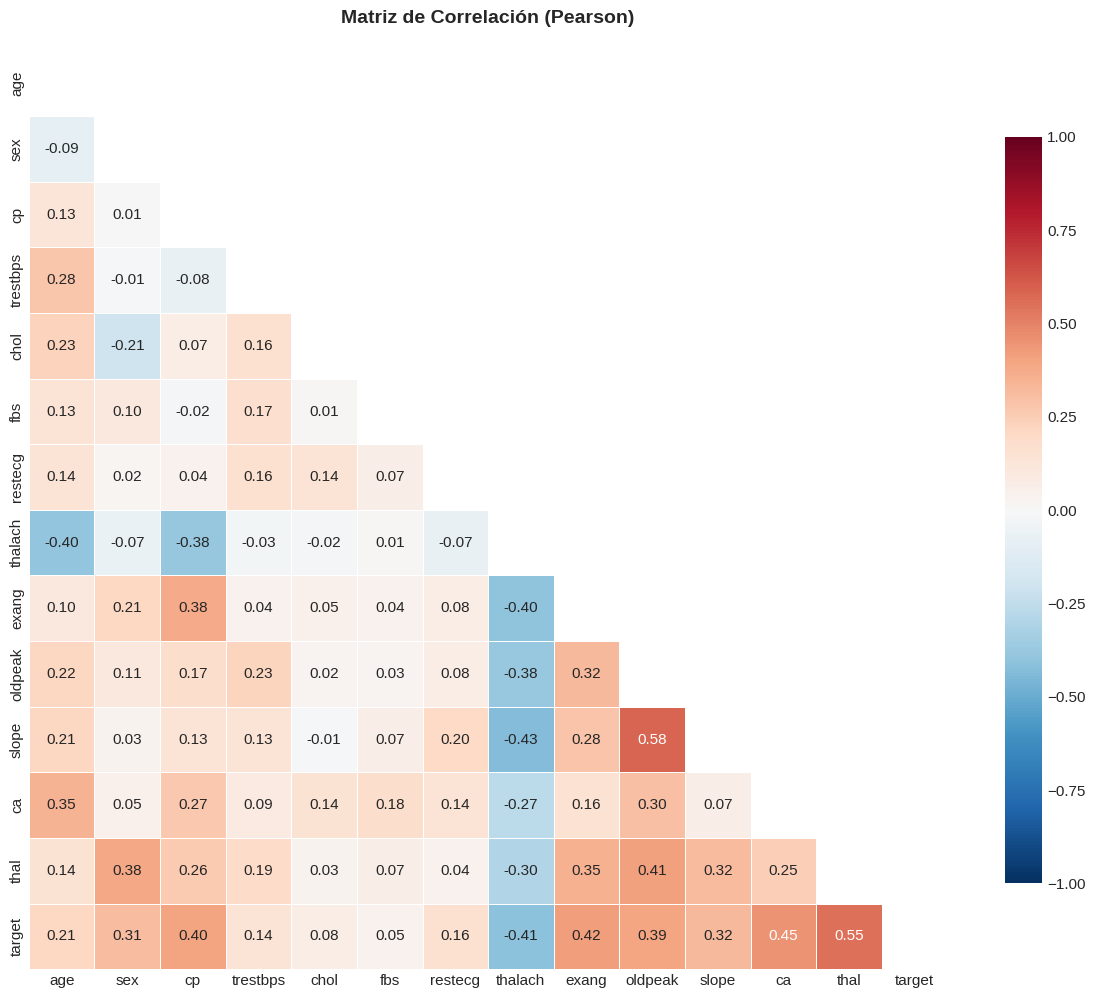

CORRELACIONES CON TARGET (ordenadas por valor absoluto)
  thal        : +0.550
  ca          : +0.453
  exang       : +0.420
  thalach     : -0.409
  cp          : +0.401
  oldpeak     : +0.392
  slope       : +0.323
  sex         : +0.308
  age         : +0.210
  restecg     : +0.160
  trestbps    : +0.136
  chol        : +0.077
  fbs         : +0.046


In [46]:
# ==============================================================================
# 5.7 MATRIZ DE CORRELACIÓN
# ==============================================================================

corr_matrix = df_train_eda.corr(numeric_only=True)

# Máscara para triángulo superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}, ax=ax)

ax.set_title('Matriz de Correlación (Pearson)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Ranking de correlaciones con target
print("="*70)
print("CORRELACIONES CON TARGET (ordenadas por valor absoluto)")
print("="*70)
target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
for var, corr in target_corr.items():
    print(f"  {var:12s}: {corr:+.3f}")

Se observan asociaciones esperables entre variables relacionadas con esfuerzo e isquemia: `thalach` (FC máxima) muestra correlación negativa con `oldpeak` y con `exang`, lo que concuerda con limitación al esfuerzo en presencia de isquemia.

En variables categóricas codificadas como enteros (p. ej., `cp`, `thal`, `slope`), la correlación lineal debe interpretarse con cautela y se complementa con análisis bivariado por categorías.

### 5.8 Análisis Bivariado: Variables Categóricas vs Target

Se comparan las variables categóricas más relevantes frente al target para visualizar patrones de asociación.

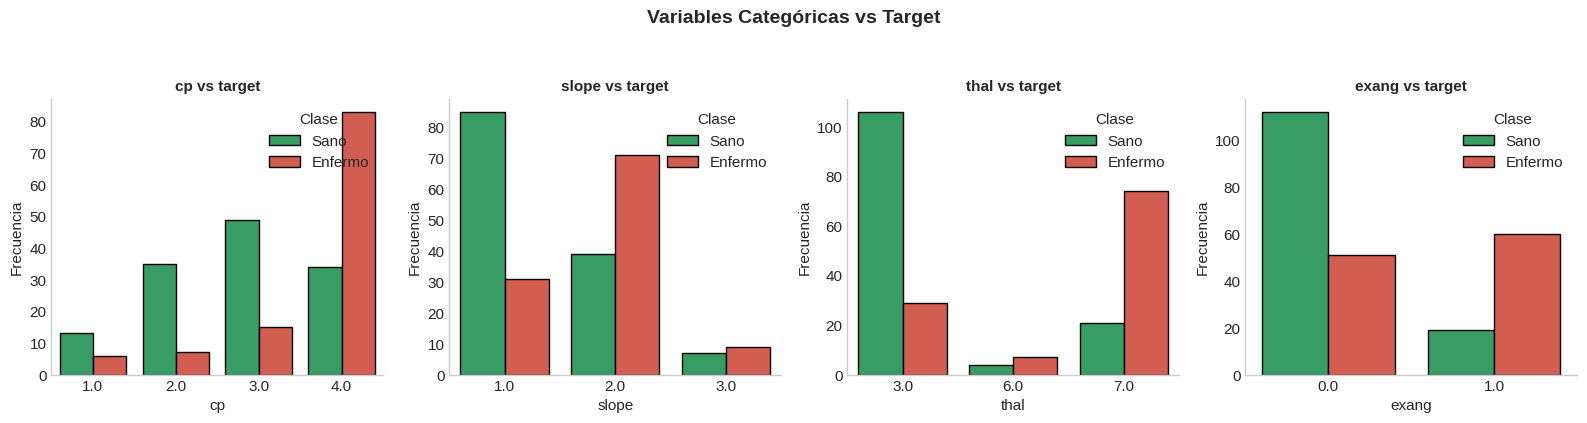

In [47]:
# ==============================================================================
# 5.8 ANÁLISIS BIVARIADO: CATEGÓRICAS VS TARGET
# ==============================================================================

cat_vars = ['cp', 'slope', 'thal', 'exang']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(cat_vars):
    ax = axes[i]

    # Ordenar categorías
    order = sorted(df_train_eda[col].dropna().unique())

    sns.countplot(data=df_train_eda, x=col, hue='target',
                  order=order, hue_order=[0, 1],
                  palette=[COLOR_SANO, COLOR_ENFERMO],
                  ax=ax, edgecolor='black', linewidth=1)

    ax.set_title(f'{col} vs target', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.legend(title='Clase', labels=['Sano', 'Enfermo'], loc='upper right')

plt.suptitle('Variables Categóricas vs Target', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Las variables con mayor asociación con el diagnóstico incluyen `thal` (talio) y `ca` (nº de vasos por fluoroscopia), seguidas de marcadores de esfuerzo/isquemia como `exang` (angina inducida por ejercicio), `oldpeak` (depresión ST) y `thalach` (FC máxima, negativa). En conjunto, esto es coherente con el proceso diagnóstico coronario (prueba funcional + hallazgos de imagen).

5.9 Interpretación del EDA

Tras analizar los resultados, se resumen los hallazgos principales que fundamentarán las decisiones de preprocesamiento.

**Calidad de los datos**

El conjunto de entrenamiento presenta buena calidad: solo se detectan **2 valores faltantes** (en `ca` *(nº de vasos principales evaluados por fluoroscopia)* y `thal` *(resultado del test de talio: normal/defecto fijo/defecto reversible)*), lo que representa **<1%** del total. Dado que ambos faltantes se concentran en variables discretas/categóricas clínicas, se aplicará imputación en el pipeline.

**Balance de clases**

La distribución del `target` (0 = sano / 1 = enfermo) muestra aproximadamente **54%** de pacientes sanos y **46%** con enfermedad. Esta proporción está suficientemente equilibrada y no requiere técnicas de reequilibrio como SMOTE o undersampling. Se mantendrá el **Recall** como métrica prioritaria dado el contexto clínico y el coste de falsos negativos.

**Outliers identificados**

Los boxplots revelan valores extremos en:

* `chol` *(colesterol sérico, mg/dl)*: valores superiores a 400 mg/dl.
* `trestbps` *(presión arterial sistólica en reposo, mmHg)*: valores por encima de 170 mmHg.
* `oldpeak` *(depresión del ST inducida por ejercicio)*: valores extremos puntuales.

Estos valores, aunque atípicos estadísticamente, pueden ser **clínicamente plausibles** y no deben eliminarse; por ello se seleccionará un escalado robusto.

**Correlaciones con el target**

Las variables con mayor asociación (por correlación absoluta) con el diagnóstico incluyen:

* `thal` *(test de talio)* y `ca` *(nº de vasos por fluoroscopia)*, con correlaciones positivas elevadas.
* `exang` *(angina inducida por ejercicio)* y `oldpeak` *(depresión del ST)*, coherentes con isquemia/limitación al esfuerzo.
* `cp` *(tipo de dolor torácico)*, consistente con la presentación clínica.

La correlación negativa de `thalach` *(frecuencia cardíaca máxima alcanzada)* es coherente clínicamente: los pacientes con enfermedad coronaria suelen alcanzar frecuencias menores durante el ejercicio por limitación funcional o aparición de síntomas.

> **Nota metodológica:** en variables categóricas codificadas como enteros (p. ej., `cp`, `slope`, `restecg`, `thal`), la correlación lineal es **orientativa**; por ello se complementa con gráficos bivariados y, en el preprocesado, se aplicará codificación one-hot.

**Variables categóricas codificadas como números**

Las variables `cp` *(tipo de dolor torácico)*, `restecg` *(ECG en reposo)*, `slope` *(pendiente del ST en esfuerzo)* y `thal` *(test de talio)* representan categorías clínicas sin orden matemático lineal. Los gráficos bivariados muestran distribuciones claramente distintas respecto al target, lo que justifica tratarlas como categóricas.

### 5.9 Decisiones de Preprocesamiento

Basándose en los hallazgos del EDA, se definen las siguientes estrategias:

**Imputación de valores faltantes**

* Variables afectadas: `ca` *(nº de vasos por fluoroscopia)* y `thal` *(test de talio)*.
* Estrategia:

  * `thal`: imputación con la **moda** (valor más frecuente), al tratarse de una variable categórica.
  * `ca`: imputación con la **mediana**, al tratarse de un conteo discreto (0–3) que se modelará como variable numérica discreta/ordinal en el pipeline.

**Codificación de variables categóricas**

* Variables: `cp` *(tipo de dolor torácico)*, `restecg` *(ECG en reposo)*, `slope` *(pendiente del ST)*, `thal` *(test de talio)*.
* Estrategia: **One-Hot Encoding**, para evitar que los modelos asuman un orden numérico inexistente entre categorías.

**Escalado de variables numéricas**

* Variables: `age` *(edad)*, `trestbps` *(PA sistólica en reposo)*, `chol` *(colesterol)*, `thalach` *(FC máxima)*, `oldpeak` *(depresión ST)*, `ca` *(conteo discreto de vasos)*.
* Estrategia: **RobustScaler**, dado que se identificaron outliers en `chol`, `trestbps` y `oldpeak`. Este escalador utiliza la mediana y el rango intercuartílico, siendo menos sensible a valores extremos que `StandardScaler`.

**Variables binarias**

* Variables: `sex` *(sexo biológico)*, `fbs` *(glucemia en ayunas >120 mg/dl)*, `exang` *(angina inducida por ejercicio)*.
* Estrategia: se dejan sin transformación (passthrough), ya que están codificadas como 0/1.

In [49]:
# ==============================================================================
# 5.10 DEFINICIÓN DE LISTAS PARA EL PIPELINE
# ==============================================================================

print("="*70)
print("DEFINICIÓN DE LISTAS PARA EL PIPELINE")
print("="*70)

# Variables categóricas nominales -> One-Hot Encoding
# Justificación: cp, restecg, slope y thal son categorías clínicas sin orden lineal
categorical_cols = ['cp', 'restecg', 'slope', 'thal']

# Variables numéricas -> RobustScaler
# Justificación: presencia de outliers en chol, trestbps y oldpeak
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# Variables binarias -> Sin transformación
# Justificación: ya están codificadas como 0/1
binary_cols = ['sex', 'fbs', 'exang']

print(f"\nCategóricas (One-Hot Encoding): {categorical_cols}")
print(f"Numéricas (RobustScaler):        {numerical_cols}")
print(f"Binarias (passthrough):          {binary_cols}")

print("\nImputación:")
print("  thal (categórica): SimpleImputer(strategy='most_frequent')")
print("  ca  (numérica discreta): SimpleImputer(strategy='median')")

print("\n" + "="*70)
print("Estas listas se utilizarán en la sección 6 para construir el Pipeline.")
print("="*70)

DEFINICIÓN DE LISTAS PARA EL PIPELINE

Categóricas (One-Hot Encoding): ['cp', 'restecg', 'slope', 'thal']
Numéricas (RobustScaler):        ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Binarias (passthrough):          ['sex', 'fbs', 'exang']

Imputación:
  thal (categórica): SimpleImputer(strategy='most_frequent')
  ca  (numérica discreta): SimpleImputer(strategy='median')

Estas listas se utilizarán en la sección 6 para construir el Pipeline.


## 6. Preprocesamiento (Pipeline)

Siguiendo las buenas prácticas metodológicas, construimos un Pipeline que integra todas las transformaciones necesarias. Esto garantiza que el preprocesamiento se aplique correctamente durante la validación cruzada, evitando data leakage.

### 6.1 Construcción del ColumnTransformer

Basándonos en los hallazgos del EDA (Sección 5.9), implementamos las siguientes transformaciones:

**Variables categóricas (One-Hot Encoding):** `cp`, `restecg`, `slope`, `thal`. Estas variables representan categorías clínicas sin orden jerárquico natural, por lo que la codificación one-hot evita que el modelo asuma relaciones ordinales inexistentes.

**Variables numéricas (RobustScaler):** `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `ca`. Se detectaron outliers clínicamente válidos en `chol`, `trestbps` y `oldpeak` durante el EDA. RobustScaler utiliza la mediana y el rango intercuartílico, siendo menos sensible a valores extremos que StandardScaler.

**Variables binarias (passthrough):** `sex`, `fbs`, `exang`. Ya están codificadas como 0/1 y no requieren transformación adicional.

**Imputación:** Las variables `ca` y `thal` presentan valores faltantes. Se imputan con la moda (valor más frecuente), estrategia apropiada para variables categóricas/discretas.

In [50]:
# ==============================================================================
# 6.1 CONSTRUCCIÓN DEL COLUMNTRANSFORMER
# ==============================================================================

print("="*70)
print("6. PREPROCESAMIENTO - CONSTRUCCIÓN DEL PIPELINE")
print("="*70)

# Definición de columnas (establecidas en el EDA)
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
binary_cols = ['sex', 'fbs', 'exang']

# Pipeline para variables categóricas: Imputación + One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Pipeline para variables numéricas: Imputación + RobustScaler
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# ColumnTransformer que combina todas las transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols),
        ('bin', 'passthrough', binary_cols)
    ],
    remainder='drop'
)

print("\nColumnTransformer configurado:")
print("-"*60)
print(f"  Numéricas (RobustScaler):    {numerical_cols}")
print(f"  Categóricas (OneHot):        {categorical_cols}")
print(f"  Binarias (passthrough):      {binary_cols}")

6. PREPROCESAMIENTO - CONSTRUCCIÓN DEL PIPELINE

ColumnTransformer configurado:
------------------------------------------------------------
  Numéricas (RobustScaler):    ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
  Categóricas (OneHot):        ['cp', 'restecg', 'slope', 'thal']
  Binarias (passthrough):      ['sex', 'fbs', 'exang']


In [51]:
# ==============================================================================
# 6.2 VERIFICACIÓN DEL PIPELINE
# ==============================================================================

print("\n" + "="*70)
print("6.2 VERIFICACIÓN DEL PIPELINE")
print("="*70)

# Transformar datos de entrenamiento para verificar
X_train_transformed = preprocessor.fit_transform(X_train)

print(f"\nDimensiones originales X_train:     {X_train.shape}")
print(f"Dimensiones transformadas X_train:  {X_train_transformed.shape}")

# Obtener nombres de las características transformadas
feature_names = (numerical_cols +
                 list(preprocessor.named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_cols)) +
                 binary_cols)

print(f"\nNúmero total de características:    {len(feature_names)}")
print(f"\nCaracterísticas generadas:")
for i, name in enumerate(feature_names):
    print(f"  {i+1:2d}. {name}")


6.2 VERIFICACIÓN DEL PIPELINE

Dimensiones originales X_train:     (242, 13)
Dimensiones transformadas X_train:  (242, 18)

Número total de características:    18

Características generadas:
   1. age
   2. trestbps
   3. chol
   4. thalach
   5. oldpeak
   6. ca
   7. cp_2.0
   8. cp_3.0
   9. cp_4.0
  10. restecg_1.0
  11. restecg_2.0
  12. slope_2.0
  13. slope_3.0
  14. thal_6.0
  15. thal_7.0
  16. sex
  17. fbs
  18. exang


## 7. Modelado y Evaluación

En esta sección se implementan y evalúan los modelos de clasificación, comenzando por un baseline que establece el rendimiento mínimo esperado. Todos los modelos se evalúan mediante validación cruzada estratificada (5-fold) para obtener estimaciones robustas del rendimiento, y se utiliza GridSearchCV para la optimización de hiperparámetros.

Dado el contexto clínico del problema, se prioriza el Recall como métrica principal para minimizar falsos negativos (pacientes enfermos clasificados como sanos).

In [52]:
# ==============================================================================
# 7.1 MODELO BASELINE - DUMMYCLASSIFIER
# ==============================================================================

print("="*70)
print("7.1 MODELO BASELINE - DUMMYCLASSIFIER")
print("="*70)

# Configuración de validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Pipeline: preprocesador + DummyClassifier
pipeline_dummy = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
])

# Evaluación con validación cruzada
scoring = ['accuracy', 'recall', 'precision', 'f1', 'roc_auc']
cv_results_dummy = {}

for metric in scoring:
    scores = cross_val_score(pipeline_dummy, X_train, y_train, cv=cv, scoring=metric)
    cv_results_dummy[metric] = {'mean': scores.mean(), 'std': scores.std()}
    print(f"{metric:12}: {scores.mean():.4f} (+/- {scores.std():.4f})")

# Entrenar para matriz de confusión
pipeline_dummy.fit(X_train, y_train)
y_pred_dummy = pipeline_dummy.predict(X_train)

print("\nMatriz de confusión (train):")
print(confusion_matrix(y_train, y_pred_dummy))

7.1 MODELO BASELINE - DUMMYCLASSIFIER
accuracy    : 0.5413 (+/- 0.0065)
recall      : 0.0000 (+/- 0.0000)
precision   : 0.0000 (+/- 0.0000)
f1          : 0.0000 (+/- 0.0000)
roc_auc     : 0.5000 (+/- 0.0000)

Matriz de confusión (train):
[[131   0]
 [111   0]]


### Interpretación del Baseline

El DummyClassifier con estrategia `most_frequent` predice siempre la clase mayoritaria (clase 0, pacientes sanos), lo que resulta en un Recall de 0% para la clase positiva. Este comportamiento es esperado y establece el umbral mínimo que cualquier modelo útil debe superar.

El accuracy de 54.1% refleja simplemente la proporción de la clase mayoritaria en el conjunto de entrenamiento. Un modelo que no supere este valor no aporta capacidad predictiva real.

Desde la perspectiva clínica, un clasificador que nunca detecta enfermedad sería inaceptable: los 111 pacientes enfermos del conjunto de entrenamiento serían dados de alta sin diagnóstico. Este baseline demuestra por qué el Recall es la métrica prioritaria en este problema.

### 7.2 Regresión Logística

La regresión logística es un modelo lineal que estima la probabilidad de pertenencia a cada clase mediante la función sigmoide. Es interpretable, computacionalmente eficiente y sirve como referencia sólida antes de probar modelos más complejos.

**Hiperparámetro principal: C (inverso de la regularización)**

El parámetro `C` controla la fuerza de la regularización L2 (Ridge) aplicada a los coeficientes. Valores pequeños de C implican mayor regularización (modelo más simple, menos riesgo de sobreajuste), mientras que valores grandes permiten coeficientes más extremos (modelo más flexible, mayor riesgo de sobreajuste).

Se explora un rango logarítmico amplio (0.001 a 100) para identificar el balance óptimo entre sesgo y varianza.

In [53]:
# ==============================================================================
# 7.2 REGRESIÓN LOGÍSTICA CON GRIDSEARCHCV
# ==============================================================================

print("="*70)
print("7.2 REGRESIÓN LOGÍSTICA")
print("="*70)

# Pipeline: preprocesador + modelo
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Espacio de hiperparámetros
param_grid_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# GridSearchCV optimizando por Recall (prioridad clínica)
grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=cv,
    scoring='recall',
    return_train_score=True,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print(f"\nMejor valor de C: {grid_lr.best_params_['classifier__C']}")
print(f"Mejor Recall (CV): {grid_lr.best_score_:.4f}")

# Evaluación completa del mejor modelo
print("\n" + "-"*50)
print("Métricas del mejor modelo (validación cruzada):")
print("-"*50)

best_lr = grid_lr.best_estimator_
for metric in scoring:
    scores = cross_val_score(best_lr, X_train, y_train, cv=cv, scoring=metric)
    print(f"{metric:12}: {scores.mean():.4f} (+/- {scores.std():.4f})")

7.2 REGRESIÓN LOGÍSTICA

Mejor valor de C: 100
Mejor Recall (CV): 0.8016

--------------------------------------------------
Métricas del mejor modelo (validación cruzada):
--------------------------------------------------
accuracy    : 0.8510 (+/- 0.0285)
recall      : 0.8016 (+/- 0.0237)
precision   : 0.8707 (+/- 0.0709)
f1          : 0.8326 (+/- 0.0257)
roc_auc     : 0.9025 (+/- 0.0152)


La regresión logística supera ampliamente al baseline en todas las métricas. El Recall de 80.2% representa una mejora sustancial frente al 0% del DummyClassifier, detectando 8 de cada 10 pacientes enfermos. El ROC-AUC de 90.3% indica una excelente capacidad para discriminar entre clases.

El valor óptimo de C=100 sugiere que el modelo se beneficia de poca regularización. Esto puede deberse a que, con solo 18 características tras el preprocesamiento y un problema relativamente bien separable, los coeficientes no necesitan ser fuertemente penalizados para evitar sobreajuste.

Las desviaciones estándar bajas en todas las métricas reflejan estabilidad del modelo entre los diferentes folds de validación cruzada.

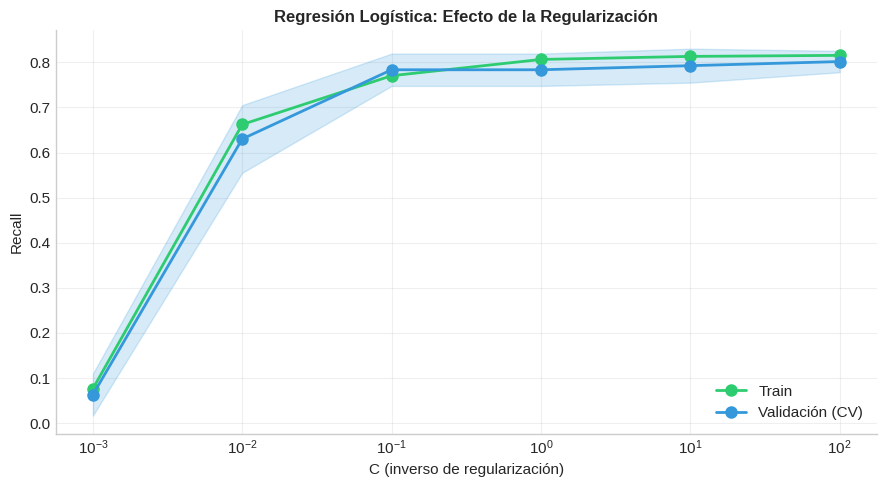

In [54]:
# ==============================================================================
# 7.2.1 ANÁLISIS DEL EFECTO DEL HIPERPARÁMETRO C
# ==============================================================================

results_lr = pd.DataFrame(grid_lr.cv_results_)

plt.figure(figsize=(9, 5))
plt.semilogx(param_grid_lr['classifier__C'], results_lr['mean_train_score'],
             'o-', label='Train', color='#2ecc71', linewidth=2, markersize=8)
plt.semilogx(param_grid_lr['classifier__C'], results_lr['mean_test_score'],
             'o-', label='Validación (CV)', color='#3498db', linewidth=2, markersize=8)

plt.fill_between(param_grid_lr['classifier__C'],
                 results_lr['mean_test_score'] - results_lr['std_test_score'],
                 results_lr['mean_test_score'] + results_lr['std_test_score'],
                 alpha=0.2, color='#3498db')

plt.xlabel('C (inverso de regularización)', fontsize=11)
plt.ylabel('Recall', fontsize=11)
plt.title('Regresión Logística: Efecto de la Regularización', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El gráfico muestra que con regularización muy fuerte (C=0.001) el modelo tiene un sesgo alto y Recall cercano a cero. A medida que C aumenta, el rendimiento mejora rápidamente hasta estabilizarse alrededor de C=0.1. A partir de ese punto, train y validación se mantienen muy cercanos, lo que indica ausencia de sobreajuste. La selección de C=100 es adecuada dado que maximiza ligeramente el Recall sin evidencia de sobreajuste.

### 7.3 Árbol de Decisión

Los árboles de decisión particionan el espacio de características mediante reglas binarias, generando modelos interpretables. A diferencia de la regresión logística, pueden capturar relaciones no lineales e interacciones entre variables sin necesidad de especificarlas explícitamente.

**Hiperparámetros principales:**

- `max_depth`: Profundidad máxima del árbol. Controla la complejidad; valores bajos previenen sobreajuste pero pueden generar subajuste.
- `min_samples_split`: Número mínimo de muestras requeridas para dividir un nodo interno. Valores altos generan árboles más simples.
- `min_samples_leaf`: Número mínimo de muestras en cada hoja. Actúa como regularización, evitando hojas con muy pocas observaciones.

Se exploran combinaciones de estos parámetros para encontrar el balance entre capacidad predictiva y generalización.

In [55]:
# ==============================================================================
# 7.3 ÁRBOL DE DECISIÓN CON GRIDSEARCHCV
# ==============================================================================

print("="*70)
print("7.3 ÁRBOL DE DECISIÓN")
print("="*70)

pipeline_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

param_grid_tree = {
    'classifier__max_depth': [2, 3, 4, 5, 6, 7, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_tree = GridSearchCV(
    pipeline_tree,
    param_grid_tree,
    cv=cv,
    scoring='recall',
    return_train_score=True,
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

print(f"\nMejores hiperparámetros:")
for param, value in grid_tree.best_params_.items():
    print(f"  {param.split('__')[1]}: {value}")
print(f"\nMejor Recall (CV): {grid_tree.best_score_:.4f}")

print("\n" + "-"*50)
print("Métricas del mejor modelo (validación cruzada):")
print("-"*50)

best_tree = grid_tree.best_estimator_
for metric in scoring:
    scores = cross_val_score(best_tree, X_train, y_train, cv=cv, scoring=metric)
    print(f"{metric:12}: {scores.mean():.4f} (+/- {scores.std():.4f})")

7.3 ÁRBOL DE DECISIÓN

Mejores hiperparámetros:
  max_depth: 2
  min_samples_leaf: 1
  min_samples_split: 2

Mejor Recall (CV): 0.7826

--------------------------------------------------
Métricas del mejor modelo (validación cruzada):
--------------------------------------------------
accuracy    : 0.7603 (+/- 0.0170)
recall      : 0.7826 (+/- 0.1512)
precision   : 0.7534 (+/- 0.1242)
f1          : 0.7436 (+/- 0.0439)
roc_auc     : 0.8248 (+/- 0.0332)


El árbol óptimo tiene profundidad máxima de 2, lo que indica que un modelo muy simple es suficiente para capturar los patrones principales. El Recall de 78.3% es ligeramente inferior al de regresión logística (80.2%), aunque con mayor variabilidad entre folds (std=0.15 vs 0.02). Esta menor estabilidad es característica de los árboles de decisión, que son sensibles a pequeñas variaciones en los datos de entrenamiento.

Los parámetros de regularización (min_samples_leaf=1, min_samples_split=2) quedaron en sus valores por defecto, lo que sugiere que la restricción de profundidad (max_depth=2) es suficiente para evitar el sobreajuste en este dataset.

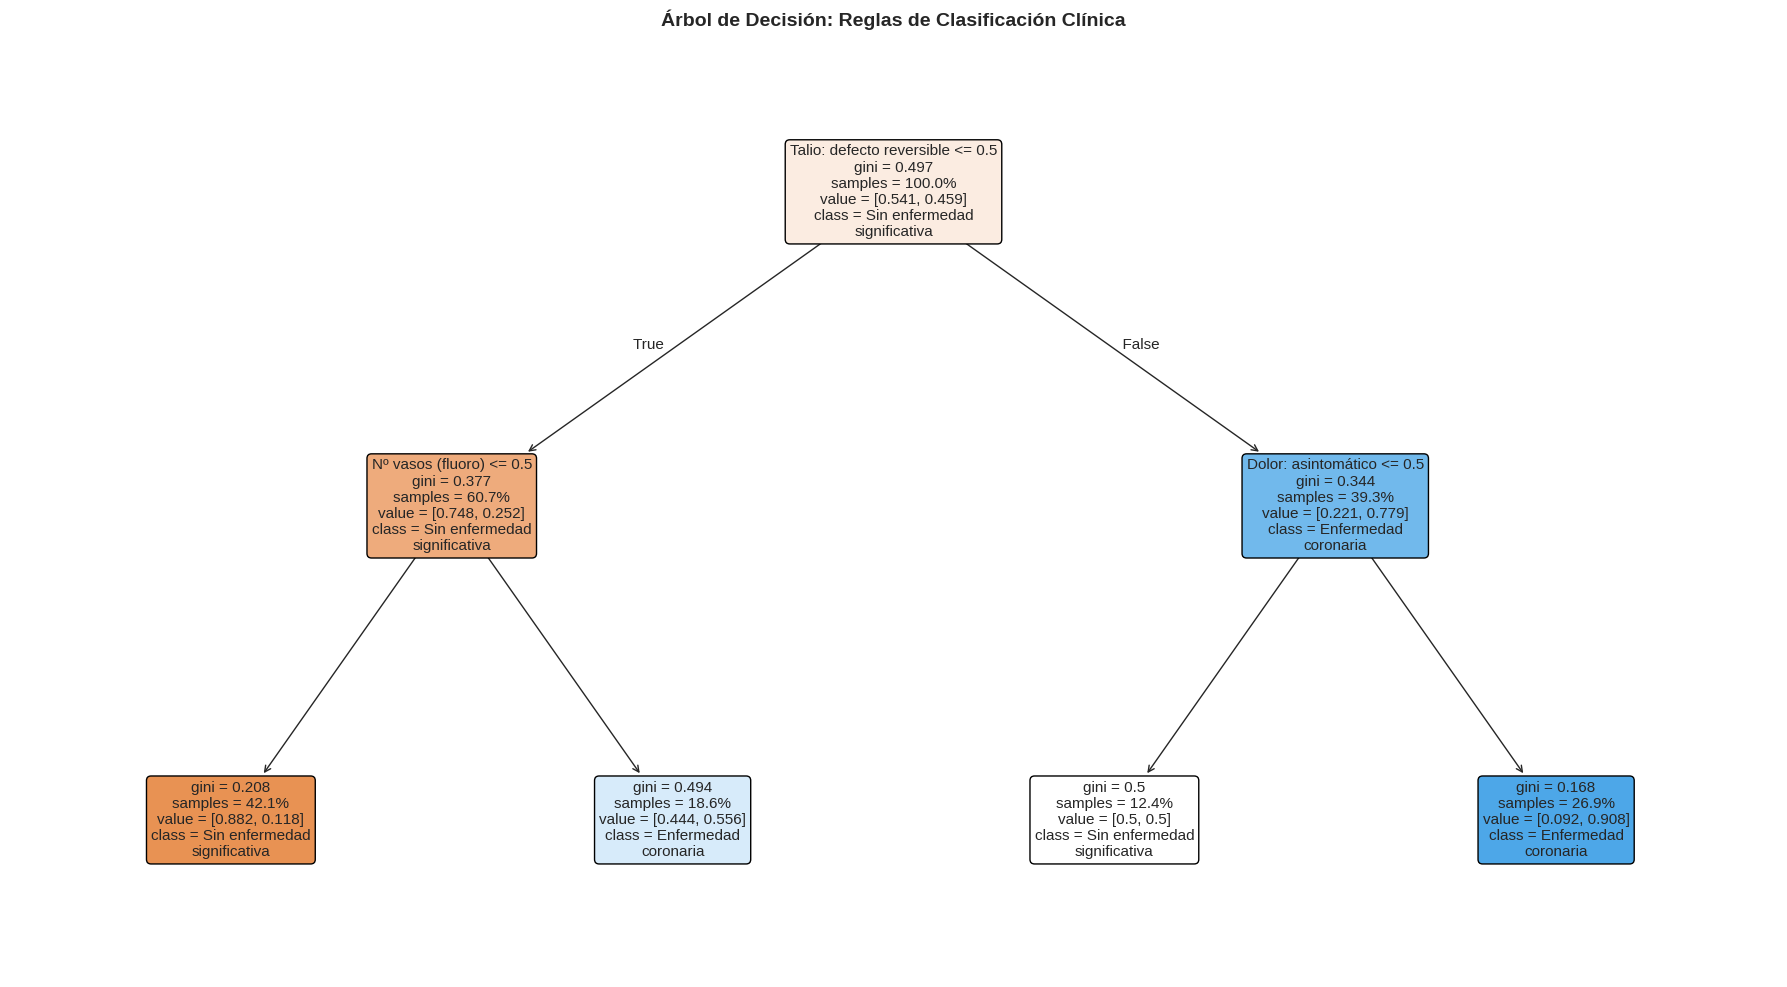

In [56]:
# ==============================================================================
# 7.3.1 VISUALIZACIÓN DEL ÁRBOL DE DECISIÓN
# ==============================================================================

# Nombres clínicos para las características
feature_names_clinical = [
    'Edad', 'PA sistólica', 'Colesterol', 'FC máxima', 'Depresión ST', 'Nº vasos (fluoro)',
    'Dolor: atípico', 'Dolor: no anginoso', 'Dolor: asintomático',
    'ECG: anormalidad ST-T', 'ECG: hipertrofia VI',
    'Pendiente ST: plana', 'Pendiente ST: descendente',
    'Talio: defecto fijo', 'Talio: defecto reversible',
    'Sexo (H)', 'Glucosa >120', 'Angina esfuerzo'
]

fig, ax = plt.subplots(figsize=(18, 10))
plot_tree(best_tree.named_steps['classifier'],
          feature_names=feature_names_clinical,
          class_names=['Sin enfermedad\nsignificativa', 'Enfermedad\ncoronaria'],
          filled=True,
          rounded=True,
          fontsize=11,
          ax=ax,
          proportion=True)
plt.title('Árbol de Decisión: Reglas de Clasificación Clínica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El árbol revela una lógica clínica coherente. La primera división utiliza el resultado del test de talio: los pacientes con defecto reversible (isquemia inducible) tienen alta probabilidad de enfermedad (rama derecha, 78% enfermos). En la rama izquierda, el número de vasos con calcio en fluoroscopia discrimina entre sanos y enfermos. El tipo de dolor torácico (asintomático vs otros) refina la clasificación en pacientes con talio anormal.

Estas variables coinciden con los predictores clínicos conocidos: el talio detecta isquemia miocárdica, la fluoroscopia identifica calcificación coronaria, y el dolor asintomático en contexto de enfermedad coronaria sugiere isquemia silente.

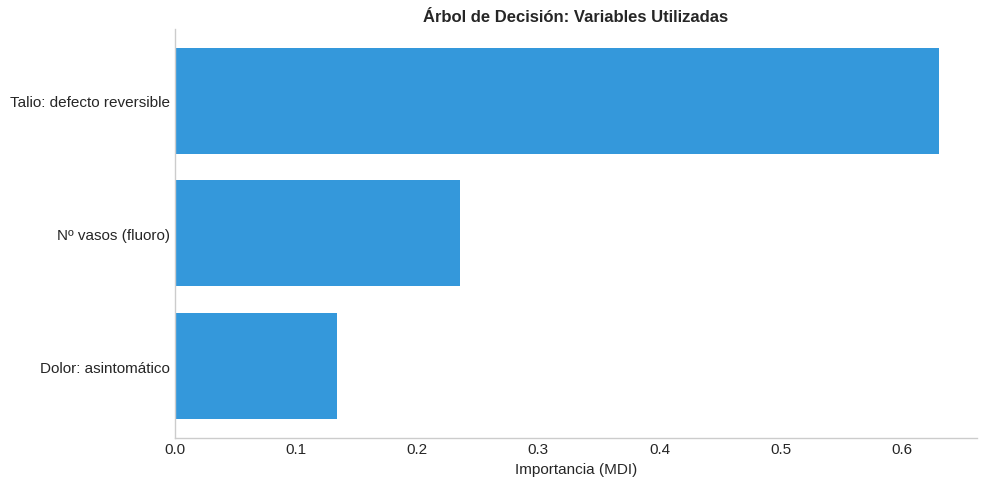

Variables utilizadas por el árbol:
  Talio: defecto reversible     : 0.6305
  Nº vasos (fluoro)             : 0.2354
  Dolor: asintomático           : 0.1341


In [57]:
# ==============================================================================
# 7.3.2 IMPORTANCIA DE CARACTERÍSTICAS (MDI)
# ==============================================================================

importances = best_tree.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[::-1]

# Filtrar solo las que tienen importancia > 0
mask = importances[indices] > 0
indices_filtered = indices[mask]

plt.figure(figsize=(10, 5))
plt.barh(range(len(indices_filtered)), importances[indices_filtered][::-1], color='#3498db')
plt.yticks(range(len(indices_filtered)), [feature_names_clinical[i] for i in indices_filtered][::-1])
plt.xlabel('Importancia (MDI)', fontsize=11)
plt.title('Árbol de Decisión: Variables Utilizadas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Variables utilizadas por el árbol:")
for i in indices_filtered:
    print(f"  {feature_names_clinical[i]:30s}: {importances[i]:.4f}")


El árbol utiliza solo 3 de las 18 variables disponibles. El test de talio (defecto reversible) concentra el 63% de la importancia, seguido del número de vasos calcificados por fluoroscopia (24%) y el tipo de dolor asintomático (13%). Es coherente con la profundidad limitada (max_depth=2) y refleja que pocas variables bien seleccionadas pueden capturar la mayor parte de la información predictiva en este problema.

### 7.4 Support Vector Machine (SVM)

Las SVM buscan el hiperplano que maximiza el margen entre clases. Con el kernel RBF (Radial Basis Function) pueden capturar fronteras de decisión no lineales, proyectando los datos a un espacio de mayor dimensión.

**Hiperparámetros principales:**

- `C`: Parámetro de regularización. Controla el trade-off entre maximizar el margen y minimizar errores de clasificación. Valores altos penalizan más los errores (margen estrecho), valores bajos permiten más violaciones (margen amplio).
- `gamma`: Define el alcance de influencia de cada punto. Valores altos generan fronteras más complejas (cada punto influye solo en su vecindad inmediata), valores bajos producen fronteras más suaves.

Se utiliza `probability=True` para obtener probabilidades calibradas necesarias para calcular ROC-AUC.

In [58]:
# ==============================================================================
# 7.4 SVM CON GRIDSEARCHCV
# ==============================================================================

print("="*70)
print("7.4 SUPPORT VECTOR MACHINE (RBF)")
print("="*70)

pipeline_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
])

param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': ['scale', 0.01, 0.1, 1]
}

grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv=cv,
    scoring='recall',
    return_train_score=True,
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print(f"\nMejores hiperparámetros:")
print(f"  C: {grid_svm.best_params_['classifier__C']}")
print(f"  gamma: {grid_svm.best_params_['classifier__gamma']}")
print(f"\nMejor Recall (CV): {grid_svm.best_score_:.4f}")

print("\n" + "-"*50)
print("Métricas del mejor modelo (validación cruzada):")
print("-"*50)

best_svm = grid_svm.best_estimator_
for metric in scoring:
    scores = cross_val_score(best_svm, X_train, y_train, cv=cv, scoring=metric)
    print(f"{metric:12}: {scores.mean():.4f} (+/- {scores.std():.4f})")

7.4 SUPPORT VECTOR MACHINE (RBF)

Mejores hiperparámetros:
  C: 1
  gamma: 0.1

Mejor Recall (CV): 0.7925

--------------------------------------------------
Métricas del mejor modelo (validación cruzada):
--------------------------------------------------
accuracy    : 0.8387 (+/- 0.0212)
recall      : 0.7925 (+/- 0.0377)
precision   : 0.8544 (+/- 0.0730)
f1          : 0.8191 (+/- 0.0167)
roc_auc     : 0.8915 (+/- 0.0165)


SVM con kernel RBF alcanza un Recall de 79.3%, comparable a regresión logística (80.2%) y árbol de decisión (78.3%). Los hiperparámetros óptimos (C=1, gamma=0.1) indican un balance moderado entre complejidad y regularización. El ROC-AUC de 89.2% confirma buena capacidad discriminativa, aunque ligeramente inferior a regresión logística (90.3%).

### 7.5 Random Forest

Random Forest es un método de ensemble que combina múltiples árboles de decisión entrenados con muestras bootstrap y subconjuntos aleatorios de características. Esta aleatorización reduce la varianza característica de los árboles individuales, generando un modelo más robusto y estable.

**Hiperparámetros principales:**

- `n_estimators`: Número de árboles en el bosque. Más árboles generalmente mejoran el rendimiento hasta estabilizarse, a costa de mayor tiempo de cómputo.
- `max_depth`: Profundidad máxima de cada árbol. Limitar la profundidad previene sobreajuste de los árboles individuales.
- `min_samples_leaf`: Número mínimo de muestras en cada hoja. Actúa como regularización adicional.

In [59]:
# ==============================================================================
# 7.5 RANDOM FOREST CON GRIDSEARCHCV
# ==============================================================================

print("="*70)
print("7.5 RANDOM FOREST")
print("="*70)

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
])

param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7, None],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=cv,
    scoring='recall',
    return_train_score=True,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print(f"\nMejores hiperparámetros:")
for param, value in grid_rf.best_params_.items():
    print(f"  {param.split('__')[1]}: {value}")
print(f"\nMejor Recall (CV): {grid_rf.best_score_:.4f}")

print("\n" + "-"*50)
print("Métricas del mejor modelo (validación cruzada):")
print("-"*50)

best_rf = grid_rf.best_estimator_
for metric in scoring:
    scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring=metric)
    print(f"{metric:12}: {scores.mean():.4f} (+/- {scores.std():.4f})")

7.5 RANDOM FOREST

Mejores hiperparámetros:
  max_depth: 7
  min_samples_leaf: 1
  n_estimators: 200

Mejor Recall (CV): 0.7830

--------------------------------------------------
Métricas del mejor modelo (validación cruzada):
--------------------------------------------------
accuracy    : 0.8181 (+/- 0.0162)
recall      : 0.7830 (+/- 0.0741)
precision   : 0.8167 (+/- 0.0333)
f1          : 0.7963 (+/- 0.0290)
roc_auc     : 0.8853 (+/- 0.0282)


Random Forest alcanza un Recall de 78.3%, similar al árbol individual pero con menor variabilidad entre folds (std=0.07 vs 0.15). Los 200 árboles con profundidad 7 generan un modelo más complejo que el árbol simple, aunque sin mejora sustancial en Recall. El ROC-AUC de 88.5% es ligeramente inferior a regresión logística y SVM, sugiriendo que la mayor complejidad del ensemble no aporta ventaja en este dataset relativamente pequeño.

### 7.6 Diagnóstico: Curvas de Aprendizaje

Las curvas de aprendizaje permiten diagnosticar problemas de sesgo (subajuste) y varianza (sobreajuste) visualizando cómo evoluciona el rendimiento en función del tamaño del conjunto de entrenamiento. Se generan para los cuatro modelos entrenados, permitiendo comparar su comportamiento.

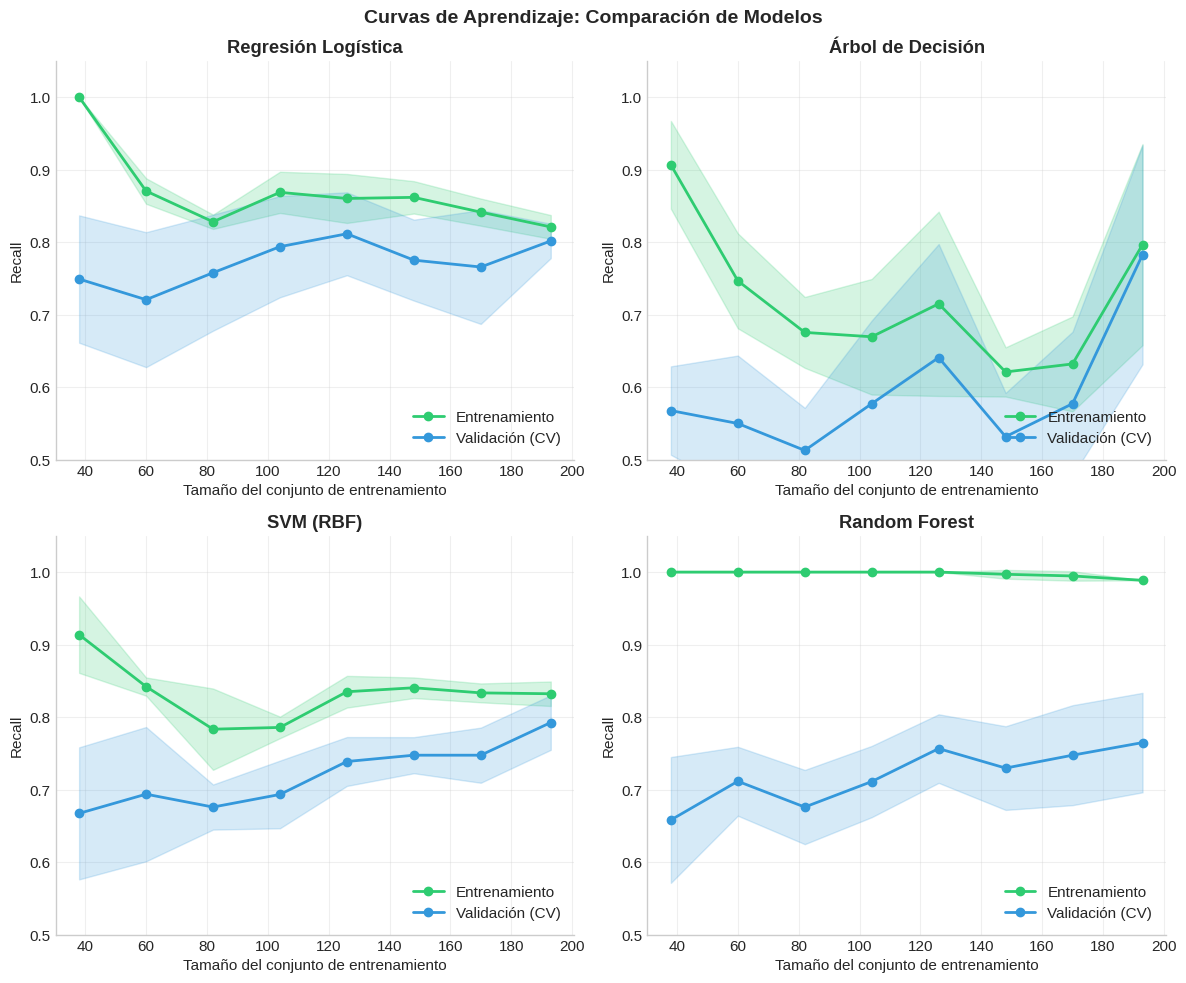

In [60]:
# ==============================================================================
# 7.6 CURVAS DE APRENDIZAJE - COMPARACIÓN DE MODELOS
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models = [
    ('Regresión Logística', best_lr),
    ('Árbol de Decisión', best_tree),
    ('SVM (RBF)', best_svm),
    ('Random Forest', best_rf)
]

for ax, (name, model) in zip(axes.flatten(), models):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        cv=cv,
        scoring='recall',
        train_sizes=np.linspace(0.2, 1.0, 8),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='#2ecc71', label='Entrenamiento', linewidth=2)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#2ecc71')
    ax.plot(train_sizes, val_mean, 'o-', color='#3498db', label='Validación (CV)', linewidth=2)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#3498db')

    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Recall')
    ax.set_title(name, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.5, 1.05])

plt.suptitle('Curvas de Aprendizaje: Comparación de Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Las curvas de aprendizaje revelan comportamientos distintos entre modelos:

**Regresión Logística** muestra convergencia entre entrenamiento y validación, indicando bajo riesgo de sobreajuste. La brecha pequeña y estable sugiere un modelo bien equilibrado.

**Árbol de Decisión** presenta alta variabilidad en validación (banda azul ancha), consistente con la inestabilidad característica de los árboles. El rendimiento fluctúa considerablemente según la partición de datos.

**SVM** exhibe una brecha moderada entre train y validación que se reduce con más datos, sugiriendo que podría beneficiarse de un dataset más grande.

**Random Forest** muestra la mayor brecha entre entrenamiento (cerca de 1.0) y validación, indicando sobreajuste a pesar de la regularización. Los 200 árboles memorizan el conjunto de entrenamiento sin traducirse en mejor generalización.

En conjunto, regresión logística ofrece el mejor balance entre rendimiento y estabilidad para este dataset.

## 8. Comparación de Modelos y Selección Final

### 8.1 Resumen de Resultados

Se presenta una comparación sistemática de todos los modelos evaluados mediante validación cruzada (5-fold). La métrica principal es el Recall, dado el contexto clínico donde minimizar falsos negativos es prioritario.

In [61]:
# ==============================================================================
# 8.1 TABLA COMPARATIVA DE MODELOS
# ==============================================================================

print("="*70)
print("8. COMPARACIÓN DE MODELOS")
print("="*70)

# Recopilar resultados de todos los modelos
models_comparison = {
    'Dummy (Baseline)': pipeline_dummy,
    'Regresión Logística': best_lr,
    'Árbol de Decisión': best_tree,
    'SVM (RBF)': best_svm,
    'Random Forest': best_rf
}

results = []
for name, model in models_comparison.items():
    row = {'Modelo': name}
    for metric in scoring:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=metric)
        row[metric] = f"{scores.mean():.3f} (+/-{scores.std():.3f})"
        row[f'{metric}_mean'] = scores.mean()
    results.append(row)

df_results = pd.DataFrame(results)

# Mostrar tabla
print("\nResultados de Validación Cruzada (5-fold):\n")
print(df_results[['Modelo', 'accuracy', 'recall', 'precision', 'f1', 'roc_auc']].to_string(index=False))

8. COMPARACIÓN DE MODELOS

Resultados de Validación Cruzada (5-fold):

             Modelo         accuracy           recall        precision               f1          roc_auc
   Dummy (Baseline) 0.541 (+/-0.006) 0.000 (+/-0.000) 0.000 (+/-0.000) 0.000 (+/-0.000) 0.500 (+/-0.000)
Regresión Logística 0.851 (+/-0.028) 0.802 (+/-0.024) 0.871 (+/-0.071) 0.833 (+/-0.026) 0.902 (+/-0.015)
  Árbol de Decisión 0.760 (+/-0.017) 0.783 (+/-0.151) 0.753 (+/-0.124) 0.744 (+/-0.044) 0.825 (+/-0.033)
          SVM (RBF) 0.839 (+/-0.021) 0.792 (+/-0.038) 0.854 (+/-0.073) 0.819 (+/-0.017) 0.891 (+/-0.016)
      Random Forest 0.818 (+/-0.016) 0.783 (+/-0.074) 0.817 (+/-0.033) 0.796 (+/-0.029) 0.885 (+/-0.028)


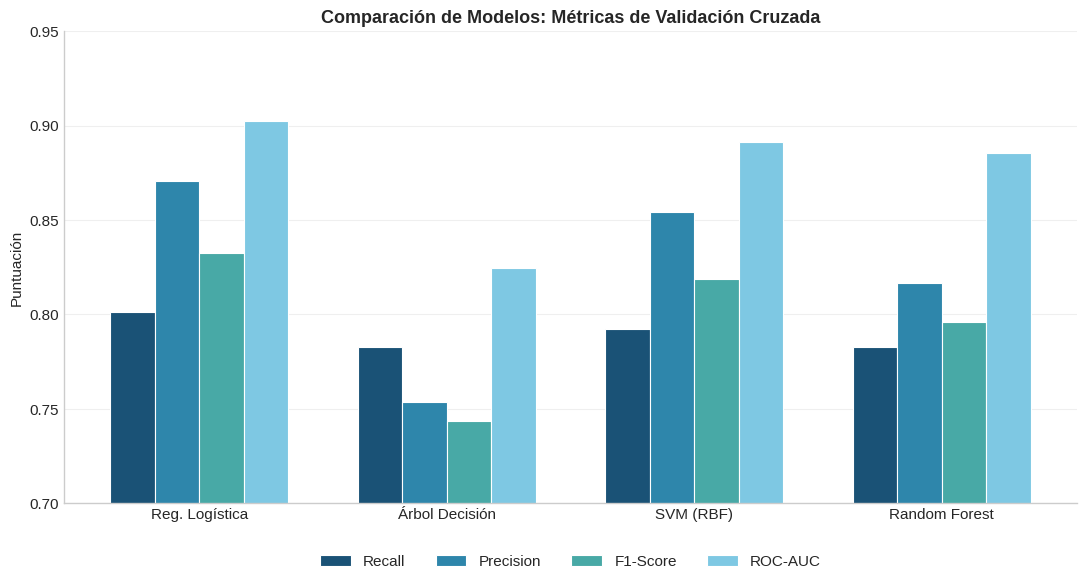

In [62]:
# ==============================================================================
# 8.2 VISUALIZACIÓN COMPARATIVA
# ==============================================================================

models_names = ['Reg. Logística', 'Árbol Decisión', 'SVM (RBF)', 'Random Forest']
metrics_to_plot = ['recall', 'precision', 'f1', 'roc_auc']
metrics_labels = ['Recall', 'Precision', 'F1-Score', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(models_names))
width = 0.18
colors = ['#1a5276', '#2e86ab', '#48a9a6', '#7ec8e3']

for i, (metric, label) in enumerate(zip(metrics_to_plot, metrics_labels)):
    values = [df_results[df_results['Modelo'].str.contains(m.split()[0])][f'{metric}_mean'].values[0]
              for m in ['Regresión', 'Árbol', 'SVM', 'Random']]
    bars = ax.bar(x + i*width, values, width, label=label, color=colors[i], edgecolor='white', linewidth=0.8)

ax.set_ylabel('Puntuación', fontsize=11)
ax.set_title('Comparación de Modelos: Métricas de Validación Cruzada', fontsize=13, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(models_names, fontsize=11)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)
ax.set_ylim([0.70, 0.95])
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

### 8.3 Selección del Modelo Final

Considerando los resultados de validación cruzada, se selecciona **Regresión Logística** como modelo final por las siguientes razones:

1. **Mejor Recall (80.2%)**: Métrica prioritaria para minimizar falsos negativos en el contexto clínico.
2. **Mayor ROC-AUC (90.2%)**: Indica la mejor capacidad discriminativa global entre todos los modelos.
3. **Estabilidad**: Presenta la menor variabilidad entre folds (std=0.024 en Recall), lo que sugiere un modelo robusto.
4. **Simplicidad e interpretabilidad**: Modelo lineal fácil de explicar clínicamente, con coeficientes que pueden relacionarse directamente con las variables predictoras.
5. **Sin sobreajuste**: Las curvas de aprendizaje mostraron convergencia entre entrenamiento y validación.

Aunque SVM y Random Forest ofrecen resultados competitivos, la regresión logística combina el mejor rendimiento con la mayor estabilidad y facilidad de interpretación clínica.

## 9. Evaluación Final en Conjunto de Test

El modelo seleccionado (Regresión Logística) se evalúa por primera y única vez en el conjunto de test, que ha permanecido completamente aislado durante todo el proceso de entrenamiento y selección. Esta evaluación proporciona una estimación honesta del rendimiento esperado en datos nuevos.

In [63]:
# ==============================================================================
# 9. EVALUACIÓN FINAL EN TEST
# ==============================================================================

print("="*70)
print("9. EVALUACIÓN FINAL EN CONJUNTO DE TEST")
print("="*70)
print("Modelo seleccionado: Regresión Logística")
print("="*70)

# Predicciones en test
y_pred = best_lr.predict(X_test)
y_prob = best_lr.predict_proba(X_test)[:, 1]

# Métricas
print("\nMétricas en conjunto de test:")
print("-"*50)
print(f"Accuracy:    {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred):.4f}")
print(f"F1-Score:    {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_prob):.4f}")

print("\n" + "-"*50)
print("Reporte de clasificación:")
print("-"*50)
print(classification_report(y_test, y_pred, target_names=['Sano', 'Enfermo']))

9. EVALUACIÓN FINAL EN CONJUNTO DE TEST
Modelo seleccionado: Regresión Logística

Métricas en conjunto de test:
--------------------------------------------------
Accuracy:    0.8525
Recall:      0.8929
Precision:   0.8065
F1-Score:    0.8475
ROC-AUC:     0.9459

--------------------------------------------------
Reporte de clasificación:
--------------------------------------------------
              precision    recall  f1-score   support

        Sano       0.90      0.82      0.86        33
     Enfermo       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



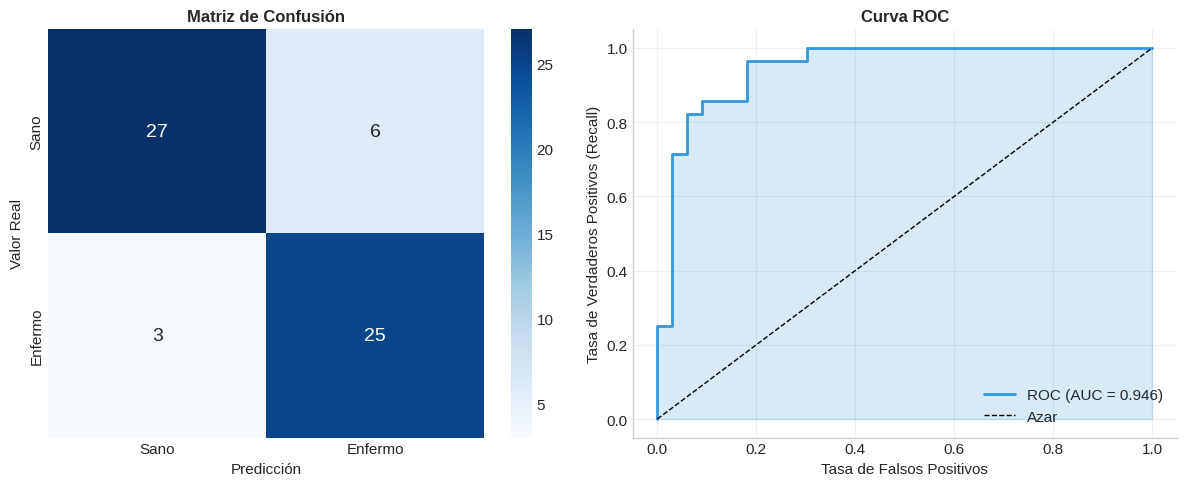


Interpretación clínica:
  Verdaderos Negativos (TN): 27 pacientes sanos correctamente identificados
  Falsos Positivos (FP):     6 pacientes sanos clasificados como enfermos
  Falsos Negativos (FN):     3 pacientes enfermos no detectados
  Verdaderos Positivos (TP): 25 pacientes enfermos correctamente identificados


In [64]:
# ==============================================================================
# 9.1 MATRIZ DE CONFUSIÓN Y CURVA ROC
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Sano', 'Enfermo'], yticklabels=['Sano', 'Enfermo'],
            annot_kws={'size': 14})
axes[0].set_xlabel('Predicción', fontsize=11)
axes[0].set_ylabel('Valor Real', fontsize=11)
axes[0].set_title('Matriz de Confusión', fontsize=12, fontweight='bold')

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

axes[1].plot(fpr, tpr, color='#3498db', linewidth=2, label=f'ROC (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Azar')
axes[1].fill_between(fpr, tpr, alpha=0.2, color='#3498db')
axes[1].set_xlabel('Tasa de Falsos Positivos', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=11)
axes[1].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretación de la matriz
tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretación clínica:")
print(f"  Verdaderos Negativos (TN): {tn} pacientes sanos correctamente identificados")
print(f"  Falsos Positivos (FP):     {fp} pacientes sanos clasificados como enfermos")
print(f"  Falsos Negativos (FN):     {fn} pacientes enfermos no detectados")
print(f"  Verdaderos Positivos (TP): {tp} pacientes enfermos correctamente identificados")

El modelo final muestra un rendimiento sólido en el conjunto de test. La matriz de confusión revela que de los 28 pacientes enfermos, el modelo identifica correctamente 25 (Recall=89.3%), fallando solo en 3 casos (falsos negativos). De los 33 pacientes sanos, clasifica correctamente 27, con 6 falsos positivos.

Desde la perspectiva clínica, los 3 falsos negativos representan pacientes enfermos que no serían derivados a angiografía, un error potencialmente grave. Sin embargo, el Recall del 89% supera ampliamente el rendimiento de muchas herramientas de screening clínico. Los 6 falsos positivos implicarían estudios adicionales innecesarios, pero este es un coste aceptable frente al riesgo de no detectar enfermedad coronaria.

La curva ROC con AUC=0.946 indica una excelente capacidad discriminativa, superior incluso a la estimada en validación cruzada (0.902). El rendimiento en test supera las estimaciones de CV en todas las métricas, sugiriendo que el modelo generaliza bien y que las estimaciones de CV fueron conservadoras.

## 10. Discusión y Conclusiones

### 10.1 Contextualización del Estudio Original

El dataset Cleveland proviene del trabajo de Detrano et al. (1989) [3], cuyo objetivo era validar una función discriminante basada en regresión logística frente al algoritmo bayesiano CADENZA para el diagnóstico de enfermedad coronaria. El estudio utilizó Cleveland (n=303) para derivar el modelo y tres centros externos para validación: Hungría (n=425), Long Beach (n=200) y Suiza (n=143).

Es relevante notar que el estudio original concluyó que la regresión logística superó al enfoque bayesiano, particularmente en poblaciones con prevalencia intermedia de enfermedad. Nuestros resultados son coherentes con esta conclusión: la regresión logística fue el modelo con mejor rendimiento global.

### 10.2 La "Zona Gris" Diagnóstica

Un aspecto clave del paper original es el énfasis en el rango de probabilidades 0.20-0.80, donde las decisiones clínicas son más difíciles. Este concepto de "zona gris" es fundamental en medicina diagnóstica: los casos extremos (muy alta o muy baja probabilidad) raramente generan dudas, mientras que los casos intermedios requieren mayor apoyo en la toma de decisiones.

Esta situación es análoga a otras áreas médicas. En anatomía patológica, por ejemplo, el diagnóstico de tejido normal o carcinoma invasor suele ser directo, mientras que las lesiones displásicas o premalignas generan mayor incertidumbre diagnóstica. Un modelo de ML orientado al soporte clínico debería optimizarse precisamente para estos casos difíciles.

### 10.3 Variables Predictoras: Perspectiva Clínica

Las variables más predictivas identificadas (test de talio con defecto reversible, número de vasos calcificados por fluoroscopia, tipo de dolor torácico) reflejan la tecnología diagnóstica de finales de los años 1980. Si bien estos hallazgos son coherentes con la fisiopatología coronaria, la práctica clínica actual ha evolucionado considerablemente:

- La fluoroscopia para calcio coronario ha sido reemplazada por el score de calcio por tomografía computarizada (TC), con mejor reproducibilidad y cuantificación.
- El test de talio ha sido complementado o sustituido por otros trazadores (Tc-99m sestamibi) y técnicas como la resonancia magnética de estrés.
- Se han incorporado biomarcadores como troponinas de alta sensibilidad y péptidos natriuréticos.

Esto limita la aplicabilidad directa del modelo a poblaciones actuales, aunque los principios subyacentes (isquemia inducible, carga aterosclerótica, presentación clínica) siguen siendo válidos.

### 10.4 Limitaciones del Dataset y Consideraciones Metodológicas

Durante el desarrollo de este proyecto se evaluó la posibilidad de combinar los cuatro centros del repositorio UCI (Cleveland, Hungría, Suiza, Long Beach) para aumentar el tamaño muestral a aproximadamente 900 pacientes. Sin embargo, este enfoque presentó desafíos importantes:

- **Valores faltantes concentrados en variables predictoras clave**: Las variables con mayor poder discriminativo (talio, fluoroscopia) presentaban alta proporción de datos ausentes, probablemente por diferencias en los protocolos diagnósticos entre centros o disponibilidad de tecnología.
- **Dilema de imputación en contexto clínico**: En variables diagnósticas, imputar con mediana o moda puede introducir sesgos clínicamente relevantes. Un estudio no realizado no es equivalente a un resultado "promedio"; puede indicar baja sospecha clínica o limitaciones del centro.
- **Heterogeneidad entre centros**: Las diferencias en prevalencia de enfermedad (38-85%) y características poblacionales sugieren que la combinación simple podría no ser apropiada.

Se optó finalmente por utilizar únicamente Cleveland, reconociendo la limitación del tamaño muestral pero preservando la coherencia metodológica.

### 10.5 Consideraciones Éticas del ML Clínico

Desde la perspectiva de implementación clínica responsable, un modelo de soporte diagnóstico debería:

- Derivarse de **estudios multicéntricos** con poblaciones diversas y bien representadas.
- Validarse en **cohortes externas** independientes.
- Evaluarse específicamente en la **zona de incertidumbre diagnóstica**, donde realmente aporta valor.
- Considerar los **costos asimétricos de los errores**: en screening cardiovascular, un falso negativo puede significar un evento coronario no prevenido.

### 10.6 Resultados y Selección del Modelo

El modelo de regresión logística fue seleccionado como modelo final, alcanzando en el conjunto de test un Recall del 89.3% y ROC-AUC del 94.6%. Estos resultados, aunque prometedores, deben interpretarse con cautela dado el tamaño limitado del conjunto de test (n=61).

La elección de regresión logística sobre modelos más complejos (SVM, Random Forest) se fundamenta en:

1. **Mejor rendimiento en la métrica prioritaria (Recall)**.
2. **Mayor estabilidad** entre folds de validación cruzada.
3. **Interpretabilidad**: Los coeficientes del modelo pueden relacionarse con odds ratios, facilitando la comunicación con profesionales clínicos.
4. **Coherencia con el estudio original**: Detrano et al. demostraron que la regresión logística superaba al enfoque bayesiano (CADENZA), estableciendo la utilidad de los modelos discriminativos en este contexto.

### 10.7 Conclusión

Este proyecto demuestra la aplicación de técnicas de Machine Learning a un problema clínico real, siguiendo una metodología rigurosa para evitar data leakage y obtener estimaciones honestas de rendimiento. El modelo final alcanza un rendimiento comparable al reportado en el estudio original de 1989, validando la utilidad de estos enfoques probabilísticos.

Sin embargo, la principal limitación es la antigüedad del dataset y su desconexión con la práctica clínica actual. Un modelo verdaderamente útil para soporte diagnóstico cardiovascular requeriría datos contemporáneos, variables acordes a la tecnología actual, y validación prospectiva multicéntrica.

El valor de este ejercicio radica en la comprensión del proceso metodológico y la integración del conocimiento clínico en cada decisión técnica, desde la elección de métricas hasta la interpretación de resultados.

## Referencias Bibliográficas

**[1]** World Health Organization. (2019). *Cardiovascular diseases (CVDs)*. WHO Fact Sheets. Disponible en: [https://www.who.int/news-room/fact-sheets/detail/cardiovascular-diseases-(cvds)](https://www.who.int/news-room/fact-sheets/detail/cardiovascular-diseases-(cvds))

**[2]** Bray, F., Laversanne, M., Weiderpass, E., & Soerjomataram, I. (2021). The ever-increasing importance of cancer as a leading cause of premature death worldwide. *Cancer*, 127(16), 3029-3030.

**[3]** Detrano, R., Janosi, A., Steinbrunn, W., et al. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. *American Journal of Cardiology*, 64(5), 304-310.

**[4]** UCI Machine Learning Repository. *Heart Disease Data Set*. Disponible en: [https://archive.ics.uci.edu/ml/datasets/heart+disease](https://archive.ics.uci.edu/ml/datasets/heart+disease)